In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
from scipy.stats import pearsonr, spearmanr
from forge_class_instance3 import FORGE as forge_optuna
from forge_ind_model_combined_optuna import  IndividualFORGE as forge_ind
%matplotlib inline

/home/sreeramp/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dep_path = "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/Fresh_FORGE/Data/Dep.csv"
ic50_path = "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/Fresh_FORGE/Data/Creammist_common_ic50.csv"
dep_data = pd.read_csv(dep_path, header = 0, index_col = 0)
ic50_data = pd.read_csv(ic50_path, header = 0, index_col = 0)
ic50_data = ic50_data.T

In [3]:
dep_data.shape, ic50_data.shape

((1076, 17916), (1325, 187))

In [ ]:
ind_model = '/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Models/combined_ind_models/ERLOTINIB_EGFR_independentModel_optuna_09012026.pkl'
joint_model_path = '/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Models/optuna_models/ERLOTINIB_EGFR_forgeModel_optuna100.pkl'

In [ ]:
joint_model = forge_optuna.load_forge(path = joint_model_path)

In [ ]:

with open(ind_model, 'rb') as f:
        ind_model_i = pickle.load(f)

In [ ]:
egfr_w = ind_model_i.W_dep
egfr_h = ind_model_i.hD
erlotinib_w = ind_model_i.W_ic50
erolitinib_h = ind_model_i.hI

In [ ]:
# compute benefit score from ind models
dep_imp_ind = pd.Series((egfr_w @ egfr_h).ravel(), index = ind_model_i.hcg_list)
ic50_imp_ind = pd.Series((erlotinib_w @ erolitinib_h).ravel(), index = ind_model_i.hcg_list)
dep_imp_ind.shape, ic50_imp_ind.shape

In [ ]:
ind_model_imp_df = pd.concat(
    [dep_imp_ind.rename('dep_imp'),
     ic50_imp_ind.rename('ic50_imp')],
    axis=1
)
ind_model_imp_df.head()

In [ ]:
ind_model_imp_df['combined'] = ind_model_imp_df['dep_imp'] - ind_model_imp_df['ic50_imp']
ind_model_imp_df['scaled_combined'] =  (ind_model_imp_df['combined'] - np.mean(ind_model_imp_df['combined'])) / np.std(ind_model_imp_df['combined'])
ind_model_imp_df.head()

In [ ]:
ind_model_imp_df.to_csv('/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Data/EGFR_ERLOTINIB_IndModel_geneImp_optuna.csv', index=True)

In [ ]:
exp_data = pd.read_csv(joint_model.exp_path, header = 0, index_col = 0)

In [ ]:
indModel_train_exp = ((exp_data.loc[ind_model_i.train_cellLines, ind_model_i.hcg_list] - ind_model_i.mean_exp)/ ind_model_i.std_exp).values
indModel_test_exp = ((exp_data.loc[ind_model_i.test_cellLines, ind_model_i.hcg_list] - ind_model_i.mean_exp)/ ind_model_i.std_exp).values
bs_train = indModel_train_exp @ ind_model_imp_df['scaled_combined']
bs_test = indModel_test_exp @ ind_model_imp_df['scaled_combined']
pred_ic50_train = indModel_train_exp @ ic50_imp_ind.values
pred_ic50_test = indModel_test_exp @ ic50_imp_ind.values
pred_dep_train = indModel_train_exp @ dep_imp_ind.values
pred_dep_test = indModel_test_exp @ dep_imp_ind.values


In [ ]:
ind_preds_df = pd.DataFrame({'pred_ic50': np.concatenate([pred_ic50_train, pred_ic50_test]),
'pred_dep': np.concatenate([pred_dep_train, pred_dep_test])}, index=np.concatenate([np.array(ind_model_i.train_cellLines), np.array(ind_model_i.test_cellLines)]))
ind_preds_df.head()

In [ ]:
ic50_data.head()

In [ ]:
train_ic50 = ic50_data.loc[ind_model_i.train_cellLines, 'ERLOTINIB'].dropna().values.reshape(-1,1)
test_ic50 = ic50_data.loc[ind_model_i.test_cellLines, 'ERLOTINIB'].dropna().values.reshape(-1,1)
train_dep = dep_data.loc[ind_model_i.train_cellLines, 'EGFR'].dropna().values.reshape(-1,1)
test_dep = dep_data.loc[ind_model_i.test_cellLines, 'EGFR'].dropna().values.reshape(-1,1)
D_train, D_test = train_dep - ind_model_i.mean_dep, test_dep - ind_model_i.mean_dep
I_train, I_test = train_ic50 - ind_model_i.mean_ic50, test_ic50 - ind_model_i.mean_ic50

In [ ]:
D_train.shape, pred_dep_train.shape

In [ ]:
train_dep_r, _ = pearsonr(x = D_train.flatten(), y=pred_dep_train)
test_dep_r, _ = pearsonr(x = D_test.flatten(), y=pred_dep_test)
train_ic50_r, _ = pearsonr(x = I_train.flatten(), y=pred_ic50_train)
test_ic50_r, _ = pearsonr(x = I_test.flatten(), y=pred_ic50_test)

In [ ]:
train_dep_r

In [ ]:
results = [
    {"var": "dep",  "set": "train", "pearson": train_dep_r},
    {"var": "dep",  "set": "test",  "pearson": test_dep_r},
    {"var": "ic50", "set": "train", "pearson": train_ic50_r},
    {"var": "ic50", "set": "test",  "pearson": test_ic50_r},
]

df_pearson = pd.DataFrame(results)
print(df_pearson)

In [ ]:
df_pearson['model_arch'] = 'ind_model'
df_pearson.head()

In [ ]:
df_pearson.to_csv('/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Data/egfr_erlotinib_joint_vs_ind.csv', index = False)

In [ ]:
# added the results from joint model
df_pearson = pd.read_csv('/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Data/egfr_erlotinib_joint_vs_ind.csv', header = 0)
df_pearson.head()

In [ ]:
z_values_df = pd.read_csv('/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Data/egfr_erlotinib_fullRes_optuna.csv', header = 0, index_col = 0)
z_values_df.head()

In [ ]:
ind_preds_df.head()

In [ ]:
z_values_df['ind_pred_ic50'] = ind_preds_df.loc[z_values_df.index, 'pred_ic50']
z_values_df['ind_pred_dep'] = ind_preds_df.loc[z_values_df.index, 'pred_dep']
z_values_df.head()

In [ ]:
z_values_df.columns

In [ ]:
pearsonr(x=z_values_df['benefit_score_scaled'], y=z_values_df['ind_pred_dep'])

In [ ]:
p_d_i, _ = pearsonr(x=z_values_df['benefit_score_scaled'], y=z_values_df['ind_pred_dep'])
p_i_i, _ = pearsonr(x=z_values_df['benefit_score_scaled'], y=z_values_df['ind_pred_ic50'])
p_d_j, _ = pearsonr(x=z_values_df['benefit_score_scaled'], y=z_values_df['pred_dep'])
p_i_j, _ = pearsonr(x=z_values_df['benefit_score_scaled'], y=z_values_df['pred_ic50'])

In [ ]:
pearson_df = pd.DataFrame([
    {"var": "dep",  "model": "joint", "pearson": p_d_j},
    {"var": "dep",  "model": "ind",  "pearson": p_d_i},
    {"var": "ic50", "model": "joint", "pearson": p_i_j},
    {"var": "ic50", "model": "ind",  "pearson": p_i_i},
])
pearson_df.head()

In [ ]:
sns.barplot(data = pearson_df, x='var', y='pearson', hue='model')

#### Multidrug forge

In [ ]:
from forge_multidrug import MultiDrugFORGE as forge_multi
model_dir = '/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Models/optuna_models'

In [ ]:
multidrug_forge = forge_multi.load_forge(path='/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Models/optuna_models/EGFR_multiDrugFORGE_optuna100.pkl')

In [ ]:
multidrug_forge.__getstate__().keys()

In [ ]:
G_train = (multidrug_forge.exp_hcg.loc[multidrug_forge.train_cellLines, multidrug_forge.hcg_list] - multidrug_forge.mean_exp) / multidrug_forge.std_exp
G_test = (multidrug_forge.exp_hcg.loc[multidrug_forge.test_cellLines, multidrug_forge.hcg_list] - multidrug_forge.mean_exp) / multidrug_forge.std_exp
G_train = G_train.values
G_test = G_test.values

In [ ]:
multidrug_forge.mean_ic50

In [ ]:
multidrug_forge.drugs

In [ ]:
gefitinib_ic50_train = (ic50_data.loc[multidrug_forge.train_cellLines, 'GEFITINIB'] - multidrug_forge.mean_ic50[1]).values.reshape(-1,1)
gefitinib_ic50_test = (ic50_data.loc[multidrug_forge.test_cellLines, 'GEFITINIB'] - multidrug_forge.mean_ic50[1]).values.reshape(-1,1)
erlotinib_ic50_train = (ic50_data.loc[multidrug_forge.train_cellLines, 'ERLOTINIB'] - multidrug_forge.mean_ic50[0]).values.reshape(-1,1)
erlotinib_ic50_test = (ic50_data.loc[multidrug_forge.test_cellLines, 'ERLOTINIB'] - multidrug_forge.mean_ic50[0]).values.reshape(-1,1)
dep_train = (dep_data.loc[multidrug_forge.train_cellLines, 'EGFR'] - multidrug_forge.mean_dep).values.reshape(-1,1)
dep_test = (dep_data.loc[multidrug_forge.test_cellLines, 'EGFR'] - multidrug_forge.mean_dep).values.reshape(-1,1)
gefitinib_ic50_train.shape, gefitinib_ic50_test.shape, erlotinib_ic50_train.shape, erlotinib_ic50_test.shape, dep_train.shape, dep_test.shape


In [ ]:
hI_df = pd.DataFrame(multidrug_forge.hI, columns = multidrug_forge.drugs)
hI_df.head()

In [ ]:
pred_train_g_ic50 = G_train @ multidrug_forge.W @ hI_df['GEFITINIB'].values.reshape(-1,1)
pred_test_g_ic50 = G_test @ multidrug_forge.W @ hI_df['GEFITINIB'].values.reshape(-1,1)
pred_train_e_ic50 = G_train @ multidrug_forge.W @ hI_df['ERLOTINIB'].values.reshape(-1,1)
pred_test_e_ic50 = G_test @ multidrug_forge.W @ hI_df['ERLOTINIB'].values.reshape(-1,1)
pred_train_d = G_train @ multidrug_forge.W @ multidrug_forge.hD
pred_test_d = G_test @ multidrug_forge.W @ multidrug_forge.hD

In [ ]:
pearson_g_train, _ = pearsonr(x=gefitinib_ic50_train, y = pred_train_g_ic50)
pearson_g_test, _ = pearsonr(x=gefitinib_ic50_test, y = pred_test_g_ic50)
pearson_e_train, _ = pearsonr(x=erlotinib_ic50_train, y = pred_train_e_ic50)
pearson_e_test, _ = pearsonr(x=erlotinib_ic50_test, y = pred_test_e_ic50)
pearson_d_train, _ = pearsonr(x=dep_train, y = pred_train_d)
pearson_d_test, _ = pearsonr(x=dep_test, y = pred_test_d)

In [ ]:
pearson_g_train

In [ ]:
print(f"Gefitinib IC50  | Train: {pearson_g_train[0]:.3f} | Test: {pearson_g_test[0]:.3f}")

In [ ]:
print(f"Gefitinib IC50  | Train: {pearson_g_train[0]:.3f} | Test: {pearson_g_test[0]:.3f}")
print(f"Erlotinib IC50 | Train: {pearson_e_train[0]:.3f} | Test: {pearson_e_test[0]:.3f}")
print(f"Dependency     | Train: {pearson_d_train[0]:.3f} | Test: {pearson_d_test[0]:.3f}")


In [ ]:
pearson_plot_df = pd.DataFrame({
    "Drug": [
        "Gefitinib IC50", "Gefitinib IC50",
        "Erlotinib IC50", "Erlotinib IC50",
        "Dependency", "Dependency"
    ],
    "Split": [
        "Train", "Test",
        "Train", "Test",
        "Train", "Test"
    ],
    "Pearson_r": [
        pearson_g_train[0], pearson_g_test[0],
        pearson_e_train[0], pearson_e_test[0],
        pearson_d_train[0], pearson_d_test[0]
    ]
})

In [ ]:
plt.figure(figsize=(10, 4))

ax = sns.barplot(
    data=pearson_plot_df,
    y="Drug", width = 0.4,
    x="Pearson_r",
    hue="Split",
    orient="h"
)

for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", padding=3)

plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Pearson correlation (r)")
plt.ylabel("")
plt.title("Train vs Test Pearson Correlation")
plt.savefig('/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Figs/multdrug_forge_corr.pdf', dpi = 300, bbox_inches = 'tight')
plt.tight_layout()
plt.show()

Gene importance plot

In [ ]:
z_values_df.head()

In [101]:
ind_model_imp_df.head()

,dep_imp,ic50_imp,combined,scaled_combined,gene,abs_imp,top_10,ic50_imp_neg
MYBL1,-0.005225,0.012718,-0.017943,-0.220607,MYBL1,0.220607,low_imp,-0.012718
UBL7-DT,-0.007510,-0.089629,0.082118,1.105452,UBL7-DT,1.105452,low_imp,0.089629
AK5,0.007211,0.022090,-0.014880,-0.180011,AK5,0.180011,low_imp,-0.022090
REPS1,0.004055,0.074455,-0.070401,-0.915801,REPS1,0.915801,low_imp,-0.074455
GGN,-0.017845,-0.087581,0.069737,0.941363,GGN,0.941363,low_imp,0.087581


In [ ]:
ind_model_imp_df['gene'] = ind_model_imp_df.index
ind_model_imp_df['abs_imp'] = ind_model_imp_df['scaled_combined'].abs()
top10_genes = ind_model_imp_df.sort_values(by='abs_imp',ascending=False).head(20).index
ind_model_imp_df['top_10'] = np.where(ind_model_imp_df['gene'].isin(top10_genes), 'top10', 'low_imp')

In [ ]:
combined_model_imp_df = pd.read_csv('/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Data/EGFR_ERLOTINIB_geneImp_optuna.csv', header = 0, index_col = 0)
combined_model_imp_df.head()

In [ ]:
combined_model_imp_df['gene'] = combined_model_imp_df.index
combined_model_imp_df['abs_imp'] = combined_model_imp_df['scaled_combined'].abs()
top10_genes = combined_model_imp_df.sort_values(by='abs_imp',ascending=False).head(20).index
combined_model_imp_df['top_10'] = np.where(combined_model_imp_df['gene'].isin(top10_genes), 'top10', 'low_imp')

In [ ]:
combined_model_imp_df['top_10'].value_counts()

In [ ]:
ind_model_imp_df['ic50_imp_neg'] = -1*ind_model_imp_df['ic50_imp']
combined_model_imp_df['ic50_imp_neg'] = -1*combined_model_imp_df['ic50_imp']

In [118]:
from adjustText import adjust_text
from scipy.stats import pearsonr, spearmanr, kendalltau
from sklearn.metrics import r2_score, mean_absolute_error

# === Updated Plotting Function ===
def plot_gene_influence_scatter(influence_df, top_n=20, mode='Ind'):
    df_scaled = influence_df.copy()
    
    # Z-score scaling
    #for col in df_scaled.columns:
    #   df_scaled[col] = (df_scaled[col] - df_scaled[col].mean()) / df_scaled[col].std()

    # Get top/bottom genes by total influence
    sorted_genes = df_scaled.sort_values("combined", ascending=False)
    top_genes = sorted_genes.head(top_n)
    bottom_genes = sorted_genes.tail(top_n)
    key_genes_df = pd.concat([top_genes, bottom_genes])
    all_key_genes = list(key_genes_df.index)
    with open(f'/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Data/keyGenes_{mode}Model_imp.txt', 'w') as f:
        f.write('\n'.join(all_key_genes))
    # === Scatter plot setup
    fig, ax = plt.subplots(figsize=(11, 11))
    # === Rasterize background points (non-key genes)
    # Mask out key genes
    non_key_genes_df = df_scaled.drop(key_genes_df.index)
    sns.set_theme(style="ticks")  # or "white" or "ticks"


    # Plot background genes in grey
    sns.scatterplot(
        data=non_key_genes_df, x="ic50_imp_neg", y="dep_imp",
        alpha= 0.9, ax=ax, rasterized=True,
        color='grey', edgecolor='black', linewidth=0.15, 
    )

    # Highlight top & bottom genes
    # === Top/bottom genes (keep editable/vector)
    sns.scatterplot(
        data=key_genes_df, x="ic50_imp_neg", y="dep_imp",
        hue=key_genes_df.index, alpha = 1, palette="Set2" , s=80, legend=False, ax=ax,
        rasterized=False  # <== key part!
    )

    # Annotate key genes
    texts = [ax.text(row["ic50_imp_neg"], row["dep_imp"], gene, fontsize=12)
             for gene, row in key_genes_df.iterrows()]
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="->", color='gray', lw=0.5))

    # Axes styling
    ax.set_title("Gene Influence on Model Predictions", fontsize=14)
    ax.set_xlabel("IC50 Effect (Sensitivity)", fontsize=14)
    ax.set_ylabel("Dependency Effect (Essentiality)", fontsize=14)
    ax.axhline(0, ls='--', color='grey')
    ax.axvline(0, ls='--', color='grey')
    
    # === Compute Metrics
    x = df_scaled["ic50_imp_neg"].values
    y = df_scaled["dep_imp"].values
    pearson_corr, pearson_p = pearsonr(x, y)
    spearman_corr, spearman_p = spearmanr(x, y)
    kendall_corr, kendall_p = kendalltau(x, y)
    r2 = r2_score(x, y)
    mae = mean_absolute_error(x, y)

    # === Add metrics box
    metrics_text = (
        f"Pearson r:   {pearson_corr:.2f} (p={pearson_p:.1e})\n"
        f"Spearman ρ:  {spearman_corr:.2f} (p={spearman_p:.1e})\n"
        #f"Kendall τ:   {kendall_corr:.2f} (p={kendall_p:.1e})\n"
        f"R² Score:    {r2:.2f}\n"
        f"MAE:         {mae:.2f}"
    )
    ax.text(0.05, 0.95, metrics_text,
            transform=ax.transAxes,
            fontsize=12,
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=1))

    # Despine top and right spines
    ax.grid(False) 
    sns.despine(top=True, right=True)
    # Set color and linewidth for axes spines (left and bottom)
    
    # === Add this block ===
    ax.tick_params(axis='both', which='both', length=8, width=2, direction='out', color='black')
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')
    
    plt.tight_layout()
    
    
    # === Save figure as PDF ===
    plt.savefig(f'/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Figs/geneImp_Plot_{mode}Model.pdf', dpi=300, bbox_inches = 'tight')
    #plt.savefig("/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/Figures_latent/ablation_study_noise/gene_influence_plot_ind_model.pdf", format="pdf", dpi=600, bbox_inches="tight")
    plt.show()




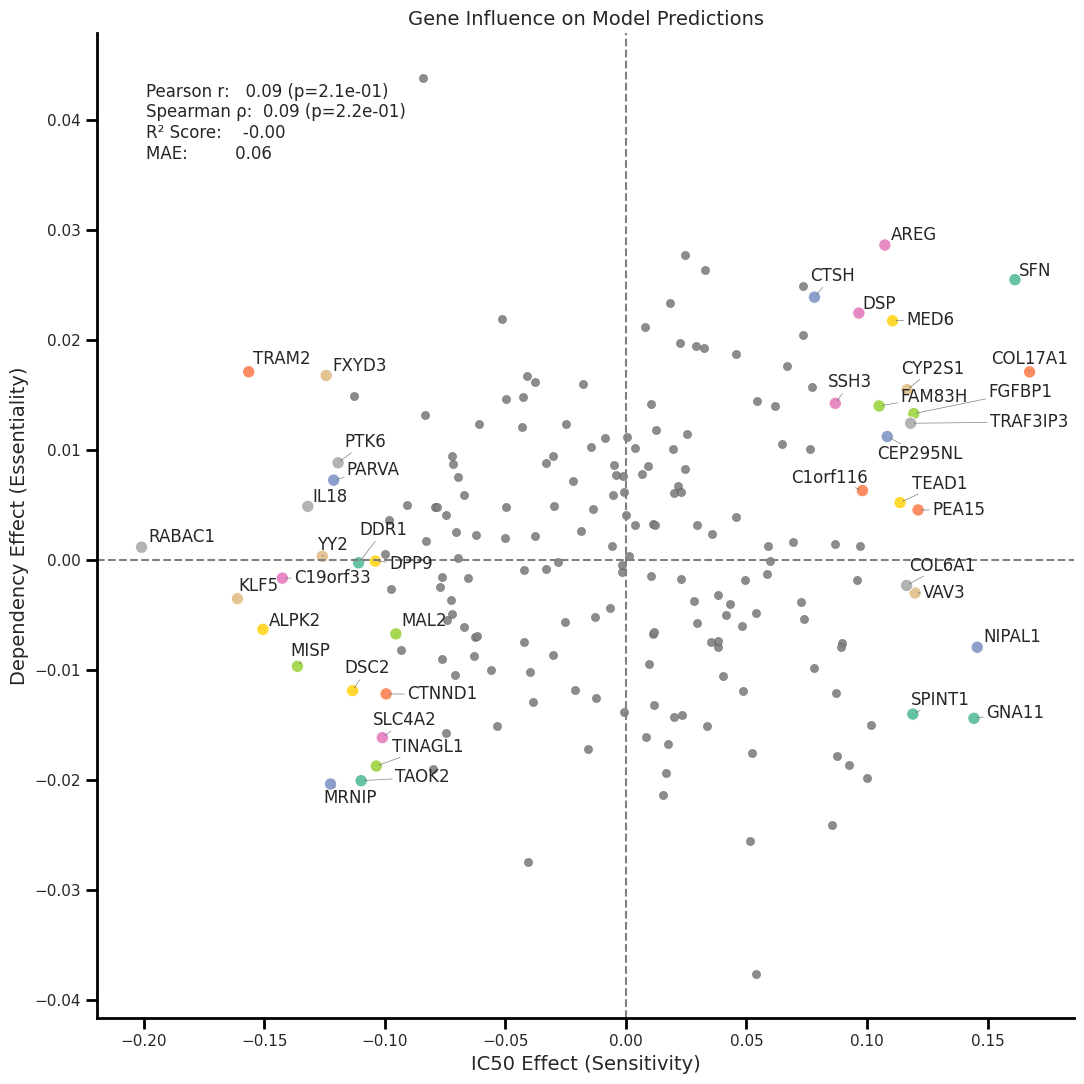

In [119]:
plot_gene_influence_scatter(ind_model_imp_df, top_n=20, mode='Ind')

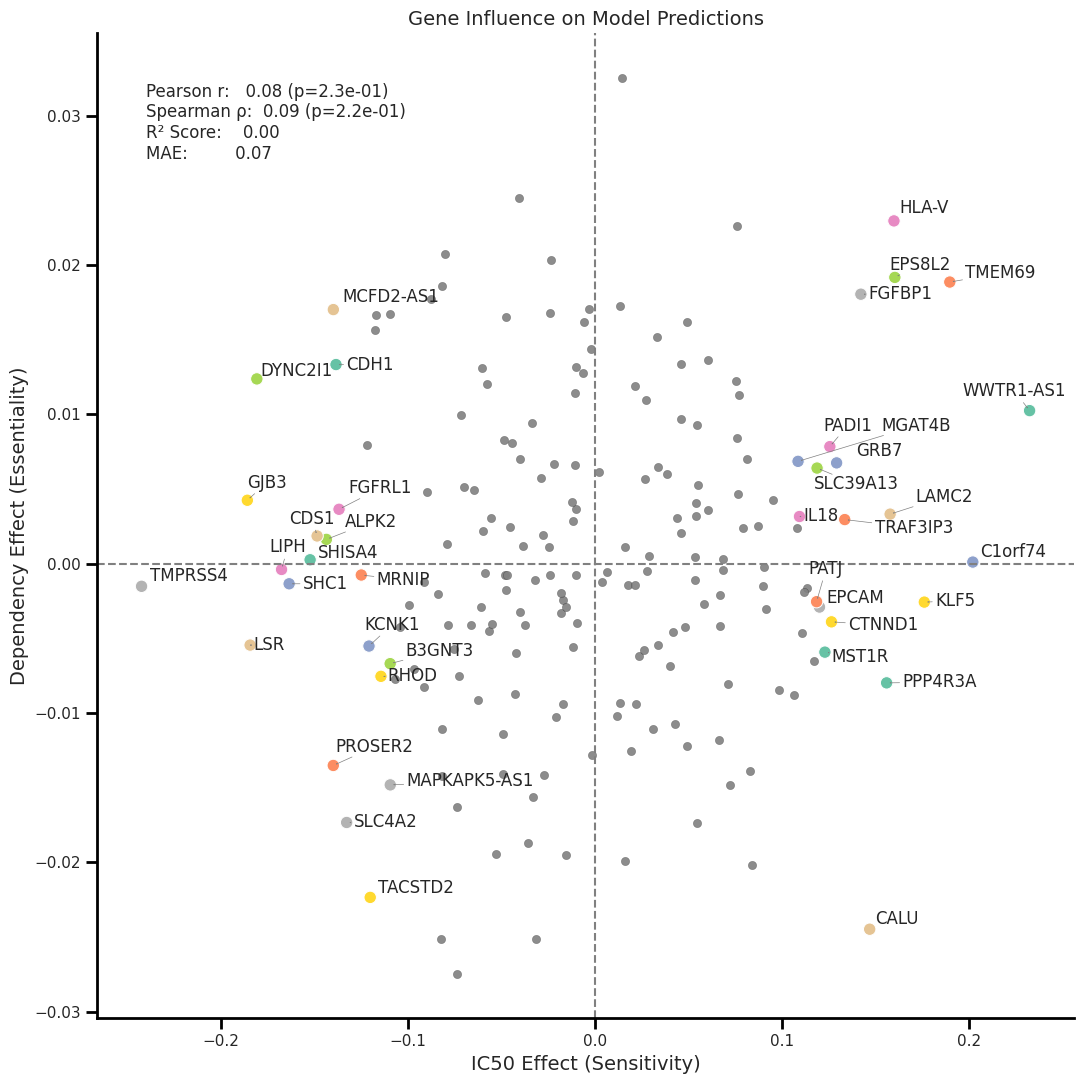

In [120]:
plot_gene_influence_scatter(combined_model_imp_df, top_n=20, mode = 'combined')

#### Analyse multiple instances

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gc
import pickle
from scipy.stats import pearsonr, spearmanr
from forge_class_instance3 import FORGE as forge_optuna
from forge_ind_model_combined_optuna import  IndividualFORGE as forge_ind
%matplotlib inline

/home/sreeramp/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dep_path = "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/Fresh_FORGE/Data/Dep.csv"
ic50_path = "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/Fresh_FORGE/Data/Creammist_common_ic50.csv"
dep_data = pd.read_csv(dep_path, header = 0, index_col = 0)
ic50_data = pd.read_csv(ic50_path, header = 0, index_col = 0)
ic50_data = ic50_data.T

In [3]:
optuna_multiple_path = '/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Models/multiSeed_optuna_indModels'
models = [i for i in os.listdir(optuna_multiple_path) if i.endswith('.pkl')]
len(models)

162

In [4]:
key_drugs = ['ERLOTINIB', 'IMATINIB', 'MK-2206', 'TIVANTINIB', 'ULIXERTINIB',
             'UPROSERTIB', 'BMS-754807', 'DABRAFENIB', 'DAPORINAD']
drug_target_data = pd.read_csv('/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/Fresh_FORGE/Data/Drug_target_data.csv',
                               header=0, index_col=0)

In [3]:
exp_path = "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/Fresh_FORGE/Data/Exp.csv"
exp_data = pd.read_csv(exp_path, header=0, index_col=0)

In [24]:
# start each model instance and get pearson of predicted vs true
ic50_pearsons_test, dep_pearsons_test = [], []
ic50_pearsons_train, dep_pearsons_train = [], []
# high_sample_ic50_pearsons, high_sample_dep_pearsons = [], []
drug_target, seed_instances, train_recs, test_recs = [], [], [], []
i = 0
for drug in key_drugs:
  target_genes = drug_target_data.loc[drug, 'Target'].split(',')
  print(f'Drug {drug}: number of targets = {len(target_genes)}')
  for target in target_genes:
    drug_target_models = [i for i in models if (drug in i) and (target in i)]
    for model_file in drug_target_models:
      with open(os.path.join(optuna_multiple_path, model_file), 'rb') as f:
        model_instance = pickle.load(f)
      # print(model_instance.__getstate__().keys())
      seed_instance = model_file.split('_')[-1].replace('.pkl','')
      hcg_exp_data = exp_data.loc[:, model_instance.hcg_list]
      train_ids = model_instance.train_cellLines
      test_ids = model_instance.test_cellLines
      G_train = (hcg_exp_data.loc[train_ids, model_instance.hcg_list] - model_instance.mean_exp) / model_instance.std_exp
      G_test = (hcg_exp_data.loc[test_ids, model_instance.hcg_list] - model_instance.mean_exp) / model_instance.std_exp
      dep_true_test = (dep_data.loc[test_ids, model_instance.target] - model_instance.mean_dep).values.reshape(-1,1)
      ic50_true_test = (ic50_data.loc[test_ids, model_instance.drug] - model_instance.mean_ic50).values.reshape(-1,1)
      dep_true_train = (dep_data.loc[train_ids, model_instance.target] - model_instance.mean_dep).values.reshape(-1,1)
      ic50_true_train = (ic50_data.loc[train_ids, model_instance.drug] - model_instance.mean_ic50).values.reshape(-1,1)
      dep_pred_test = (G_test @ model_instance.W_dep @ model_instance.hD).to_numpy()
      ic50_pred_test = (G_test @ model_instance.W_ic50 @ model_instance.hI).to_numpy()
      dep_pred_train = (G_train @ model_instance.W_dep @ model_instance.hD).to_numpy()
      ic50_pred_train = (G_train @ model_instance.W_ic50 @ model_instance.hI).to_numpy()
      dep_pearson_test, _ = pearsonr(dep_true_test.flatten(), dep_pred_test.flatten())
      ic50_pearson_test, _ = pearsonr(ic50_true_test.flatten(), ic50_pred_test.flatten())
      dep_pearsons_test.append(dep_pearson_test)
      ic50_pearsons_test.append(ic50_pearson_test)
      dep_pearson_train, _ = pearsonr(dep_true_train.flatten(), dep_pred_train.flatten())
      ic50_pearson_train, _ = pearsonr(ic50_true_train.flatten(), ic50_pred_train.flatten())
      dep_pearsons_train.append(dep_pearson_train)
      ic50_pearsons_train.append(ic50_pearson_train)
      # print(model_file, dep_pearson_test, ic50_pearson_test)
      drug_target.append(f'{model_instance.drug}_{model_instance.target}')
      seed_instances.append(seed_instance)
      train_recs.append('train')
      test_recs.append('test')
      i += 1
      del model_instance
      gc.collect()

Drug ERLOTINIB: number of targets = 1
Drug IMATINIB: number of targets = 6
Drug MK-2206: number of targets = 3
Drug TIVANTINIB: number of targets = 1
Drug ULIXERTINIB: number of targets = 2
Drug UPROSERTIB: number of targets = 3
Drug BMS-754807: number of targets = 2
Drug DABRAFENIB: number of targets = 1
Drug DAPORINAD: number of targets = 1


In [25]:
i

162

In [26]:
train_res_df = pd.DataFrame({
  'drug_target': drug_target,
  'seed_instance': seed_instances,
  'set': train_recs,
  'dep_pearson': dep_pearsons_train,
  'ic50_pearson': ic50_pearsons_train
})

train_res_df.head()

,drug_target,seed_instance,set,dep_pearson,ic50_pearson
0,ERLOTINIB_EGFR,161287,train,0.672981,0.564103
1,ERLOTINIB_EGFR,11111222,train,0.061318,0.142092
2,ERLOTINIB_EGFR,227745,train,0.275837,-0.213420
3,ERLOTINIB_EGFR,228796,train,0.243727,-0.313037
4,ERLOTINIB_EGFR,321456,train,0.282209,0.277744


In [27]:
train_res_df['model_name'] = train_res_df['drug_target'] + '_' + train_res_df['seed_instance']
train_res_df.head()

,drug_target,seed_instance,set,dep_pearson,ic50_pearson,model_name
0,ERLOTINIB_EGFR,161287,train,0.672981,0.564103,ERLOTINIB_EGFR_161287
1,ERLOTINIB_EGFR,11111222,train,0.061318,0.142092,ERLOTINIB_EGFR_11111222
2,ERLOTINIB_EGFR,227745,train,0.275837,-0.213420,ERLOTINIB_EGFR_227745
3,ERLOTINIB_EGFR,228796,train,0.243727,-0.313037,ERLOTINIB_EGFR_228796
4,ERLOTINIB_EGFR,321456,train,0.282209,0.277744,ERLOTINIB_EGFR_321456


In [28]:
test_res_df = pd.DataFrame({
  'drug_target': drug_target,
  'seed_instance': seed_instances,
  'set': test_recs,
  'dep_pearson': dep_pearsons_test,
  'ic50_pearson': ic50_pearsons_test
})

test_res_df.head()

,drug_target,seed_instance,set,dep_pearson,ic50_pearson
0,ERLOTINIB_EGFR,161287,test,0.560501,0.385397
1,ERLOTINIB_EGFR,11111222,test,0.090852,0.247024
2,ERLOTINIB_EGFR,227745,test,0.301627,-0.150771
3,ERLOTINIB_EGFR,228796,test,0.332580,-0.214139
4,ERLOTINIB_EGFR,321456,test,0.131007,0.119846


In [29]:
test_res_df['model_name'] = test_res_df['drug_target'] + '_' + test_res_df['seed_instance']
test_res_df.head()

,drug_target,seed_instance,set,dep_pearson,ic50_pearson,model_name
0,ERLOTINIB_EGFR,161287,test,0.560501,0.385397,ERLOTINIB_EGFR_161287
1,ERLOTINIB_EGFR,11111222,test,0.090852,0.247024,ERLOTINIB_EGFR_11111222
2,ERLOTINIB_EGFR,227745,test,0.301627,-0.150771,ERLOTINIB_EGFR_227745
3,ERLOTINIB_EGFR,228796,test,0.332580,-0.214139,ERLOTINIB_EGFR_228796
4,ERLOTINIB_EGFR,321456,test,0.131007,0.119846,ERLOTINIB_EGFR_321456


In [30]:
full_res = pd.concat([train_res_df, test_res_df], axis=0)
full_res.head()

,drug_target,seed_instance,set,dep_pearson,ic50_pearson,model_name
0,ERLOTINIB_EGFR,161287,train,0.672981,0.564103,ERLOTINIB_EGFR_161287
1,ERLOTINIB_EGFR,11111222,train,0.061318,0.142092,ERLOTINIB_EGFR_11111222
2,ERLOTINIB_EGFR,227745,train,0.275837,-0.213420,ERLOTINIB_EGFR_227745
3,ERLOTINIB_EGFR,228796,train,0.243727,-0.313037,ERLOTINIB_EGFR_228796
4,ERLOTINIB_EGFR,321456,train,0.282209,0.277744,ERLOTINIB_EGFR_321456


In [31]:
full_res['set'].value_counts()

set
train    162
test     162
Name: count, dtype: int64

In [4]:
drug_target_list = [
    "UPROSERTIB_AKT1",
    "ULIXERTINIB_MAPK1",
    "TIVANTINIB_MET",
    "MK-2206_AKT1",
    "IMATINIB_MCL1",
    "DABRAFENIB_BRAF",
    "BMS-754807_IGF1R",
    "AZD8931_ERBB2",
    "DAPORINAD_NAMPT"
]

In [ ]:
filtered_res_df = full_res.loc[full_res['drug_target'].isin(drug_target_list), :]
filtered_res_df.shape

(144, 6)

In [39]:
filtered_res_df.to_csv('/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Data/Ind_multInstance_corr.csv', index=False)

In [33]:
filtered_res_df.head()

,drug_target,seed_instance,set,dep_pearson,ic50_pearson,model_name
27,IMATINIB_MCL1,586231,train,-0.219526,-0.105954,IMATINIB_MCL1_586231
28,IMATINIB_MCL1,11111222,train,0.366531,-0.150583,IMATINIB_MCL1_11111222
29,IMATINIB_MCL1,321456,train,0.054739,0.307372,IMATINIB_MCL1_321456
30,IMATINIB_MCL1,12587,train,-0.222521,0.374570,IMATINIB_MCL1_12587
31,IMATINIB_MCL1,161287,train,0.182477,0.246994,IMATINIB_MCL1_161287


In [7]:
filtered_res_df = pd.read_csv('/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Data/Ind_multInstance_corr.csv', header = 0)

In [8]:
agg = (
    filtered_res_df
    .melt(
        id_vars=["drug_target", "seed_instance", "set"],
        value_vars=["dep_pearson", "ic50_pearson"],
        var_name="endpoint",
        value_name="pearson"
    )
    .groupby(["drug_target", "set", "endpoint"])
    .agg(
        mean_pearson=("pearson", "mean"),
        sem_pearson=("pearson", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        n=("pearson", "count")
    )
    .reset_index()
)
agg.head()

,drug_target,set,endpoint,mean_pearson,sem_pearson,n
0,BMS-754807_IGF1R,test,dep_pearson,-0.048356,0.044551,9
1,BMS-754807_IGF1R,test,ic50_pearson,0.040664,0.070645,9
2,BMS-754807_IGF1R,train,dep_pearson,0.012178,0.046398,9
3,BMS-754807_IGF1R,train,ic50_pearson,0.037896,0.055934,9
4,DABRAFENIB_BRAF,test,dep_pearson,0.032672,0.058476,9


In [9]:
drug_targets = agg["drug_target"].unique()
y_base = np.arange(len(drug_targets))

offsets = {
    ("dep_pearson", "train"): -0.3,
    ("dep_pearson", "test"):  -0.1,
    ("ic50_pearson", "train"): 0.1,
    ("ic50_pearson", "test"):  0.3,
}

bar_height = 0.18

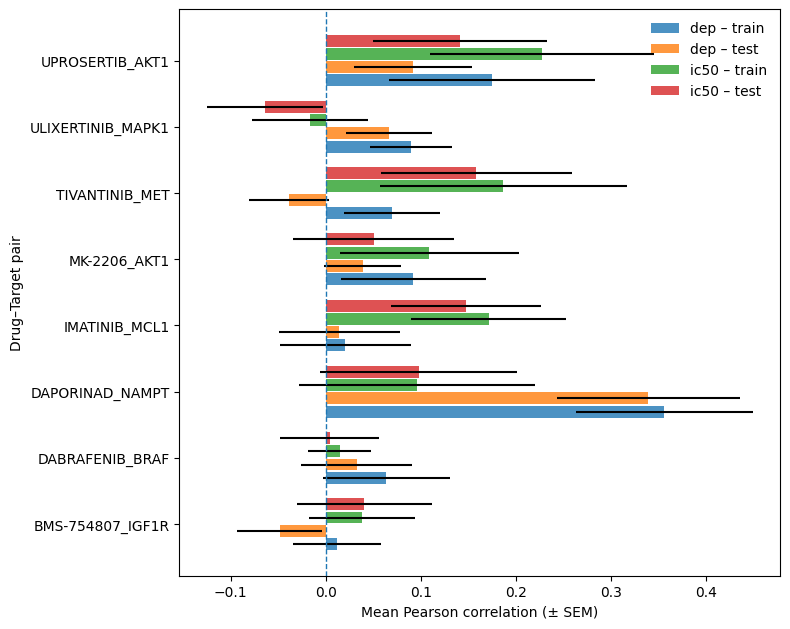

In [10]:
plt.figure(figsize=(8, 0.8 * len(drug_targets)))

for (endpoint, split), offset in offsets.items():
    subset = agg[
        (agg["endpoint"] == endpoint) &
        (agg["set"] == split)
    ]

    y = [
        y_base[list(drug_targets).index(dt)] + offset
        for dt in subset["drug_target"]
    ]

    plt.barh(
        y,
        subset["mean_pearson"],
        xerr=subset["sem_pearson"],
        height=bar_height,
        label=f"{endpoint.replace('_pearson','')} – {split}",
        alpha=0.8
    )

plt.axvline(0, linestyle="--", linewidth=1)

plt.yticks(y_base, drug_targets)
plt.xlabel("Mean Pearson correlation (± SEM)")
plt.ylabel("Drug–Target pair")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig('/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Figs/IndModels_pearsons.pdf', dpi=300, bbox_inches='tight')
plt.show()


#### Multiple instances of joint models

In [48]:
joint_instances_dir = '/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Models/multiSeed_optuna'
models = [i for i in os.listdir(joint_instances_dir) if i.endswith('.pkl')]
models = [i for i in models if 'Ind' not in i]
len(models)

162

In [49]:
# start each model instance and get pearson of predicted vs true
ic50_pearsons_test, dep_pearsons_test = [], []
ic50_pearsons_train, dep_pearsons_train = [], []
# high_sample_ic50_pearsons, high_sample_dep_pearsons = [], []
drug_target, seed_instances, train_recs, test_recs = [], [], [], []
i = 0
for drug in key_drugs:
  target_genes = drug_target_data.loc[drug, 'Target'].split(',')
  print(f'Drug {drug}: number of targets = {len(target_genes)}')
  for target in target_genes:
    drug_target_models = [i for i in models if (drug in i) and (target in i)]
    for model_file in drug_target_models:
      print(model_file)
      model_instance = forge_optuna.load_forge(path=os.path.join(joint_instances_dir, model_file))
      # print(model_instance.__getstate__().keys())
      seed_instance = model_file.split('_')[-1].replace('.pkl','')
      hcg_exp_data = exp_data.loc[:, model_instance.hcg_list]
      train_ids = model_instance.train_cellLines
      test_ids = model_instance.test_cellLines
      G_train = (hcg_exp_data.loc[train_ids, model_instance.hcg_list] - model_instance.mean_exp) / model_instance.std_exp
      G_test = (hcg_exp_data.loc[test_ids, model_instance.hcg_list] - model_instance.mean_exp) / model_instance.std_exp
      dep_true_test = (dep_data.loc[test_ids, model_instance.target] - model_instance.mean_dep).values.reshape(-1,1)
      ic50_true_test = (ic50_data.loc[test_ids, model_instance.drug] - model_instance.mean_ic50).values.reshape(-1,1)
      dep_true_train = (dep_data.loc[train_ids, model_instance.target] - model_instance.mean_dep).values.reshape(-1,1)
      ic50_true_train = (ic50_data.loc[train_ids, model_instance.drug] - model_instance.mean_ic50).values.reshape(-1,1)
      dep_pred_test = (G_test @ model_instance.W @ model_instance.hD).to_numpy()
      ic50_pred_test = (G_test @ model_instance.W @ model_instance.hI).to_numpy()
      dep_pred_train = (G_train @ model_instance.W @ model_instance.hD).to_numpy()
      ic50_pred_train = (G_train @ model_instance.W @ model_instance.hI).to_numpy()
      dep_pearson_test, _ = pearsonr(dep_true_test.flatten(), dep_pred_test.flatten())
      ic50_pearson_test, _ = pearsonr(ic50_true_test.flatten(), ic50_pred_test.flatten())
      dep_pearsons_test.append(dep_pearson_test)
      ic50_pearsons_test.append(ic50_pearson_test)
      dep_pearson_train, _ = pearsonr(dep_true_train.flatten(), dep_pred_train.flatten())
      ic50_pearson_train, _ = pearsonr(ic50_true_train.flatten(), ic50_pred_train.flatten())
      dep_pearsons_train.append(dep_pearson_train)
      ic50_pearsons_train.append(ic50_pearson_train)
      # print(model_file, dep_pearson_test, ic50_pearson_test)
      drug_target.append(f'{model_instance.drug}_{model_instance.target}')
      seed_instances.append(seed_instance)
      train_recs.append('train')
      test_recs.append('test')
      i += 1
      del model_instance
      gc.collect()

Drug ERLOTINIB: number of targets = 1
ERLOTINIB_EGFR_forgeModel_optuna100_161287.pkl
ERLOTINIB_EGFR_forgeModel_optuna100_586231.pkl
ERLOTINIB_EGFR_forgeModel_optuna100_321456.pkl
ERLOTINIB_EGFR_forgeModel_optuna100_227745.pkl
ERLOTINIB_EGFR_forgeModel_optuna100_23698.pkl
ERLOTINIB_EGFR_forgeModel_optuna100_228796.pkl
ERLOTINIB_EGFR_forgeModel_optuna100_42.pkl
ERLOTINIB_EGFR_forgeModel_optuna100_12587.pkl
ERLOTINIB_EGFR_forgeModel_optuna100_11111222.pkl
Drug IMATINIB: number of targets = 6
IMATINIB_ABL1_forgeModel_optuna100_11111222.pkl
IMATINIB_ABL1_forgeModel_optuna100_228796.pkl
IMATINIB_ABL1_forgeModel_optuna100_42.pkl
IMATINIB_ABL1_forgeModel_optuna100_586231.pkl
IMATINIB_ABL1_forgeModel_optuna100_12587.pkl
IMATINIB_ABL1_forgeModel_optuna100_227745.pkl
IMATINIB_ABL1_forgeModel_optuna100_321456.pkl
IMATINIB_ABL1_forgeModel_optuna100_161287.pkl
IMATINIB_ABL1_forgeModel_optuna100_23698.pkl
IMATINIB_BCR_forgeModel_optuna100_321456.pkl
IMATINIB_BCR_forgeModel_optuna100_161287.pkl
IMATIN

In [50]:
i

162

In [51]:
train_res_df_j = pd.DataFrame({
  'drug_target': drug_target,
  'seed_instance': seed_instances,
  'set': train_recs,
  'dep_pearson': dep_pearsons_train,
  'ic50_pearson': ic50_pearsons_train
})

test_res_df_j = pd.DataFrame({
  'drug_target': drug_target,
  'seed_instance': seed_instances,
  'set': test_recs,
  'dep_pearson': dep_pearsons_test,
  'ic50_pearson': ic50_pearsons_test
})

full_res_joint = pd.concat([train_res_df_j, test_res_df_j], axis = 0)
full_res_joint['model_name'] = full_res_joint['drug_target'] + '_' + full_res_joint['seed_instance']
filtered_res_df_joint = full_res_joint.loc[full_res_joint['model_name'].isin(full_res['model_name']), :]
filtered_res_df_joint.shape


(324, 6)

In [52]:
full_res_joint.to_csv('/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Data/multInstance_joint_corr.csv', index=False)

In [11]:
full_res_joint = pd.read_csv('/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Data/multInstance_joint_corr.csv', header = 0)
full_res_joint.head()

,drug_target,seed_instance,set,dep_pearson,ic50_pearson,model_name
0,ERLOTINIB_EGFR,161287,train,0.560761,0.594100,ERLOTINIB_EGFR_161287
1,ERLOTINIB_EGFR,586231,train,0.572810,0.629301,ERLOTINIB_EGFR_586231
2,ERLOTINIB_EGFR,321456,train,0.610158,0.587817,ERLOTINIB_EGFR_321456
3,ERLOTINIB_EGFR,227745,train,0.590472,0.555626,ERLOTINIB_EGFR_227745
4,ERLOTINIB_EGFR,23698,train,0.612105,0.559025,ERLOTINIB_EGFR_23698


In [15]:
drug_target_list = [
    "UPROSERTIB_AKT1",
    "ULIXERTINIB_MAPK1",
    "TIVANTINIB_MET",
    "MK-2206_AKT1",
    "IMATINIB_MCL1",
    "DABRAFENIB_BRAF",
    "BMS-754807_IGF1R",
    "AZD8931_ERBB2",
    "DAPORINAD_NAMPT"
]
full_res_joint_f = full_res_joint.loc[full_res_joint['drug_target'].isin(drug_target_list), :]
full_res_joint_f.shape

(144, 6)

In [16]:
agg = (
    full_res_joint_f
    .melt(
        id_vars=["drug_target", "seed_instance", "set"],
        value_vars=["dep_pearson", "ic50_pearson"],
        var_name="endpoint",
        value_name="pearson"
    )
    .groupby(["drug_target", "set", "endpoint"])
    .agg(
        mean_pearson=("pearson", "mean"),
        sem_pearson=("pearson", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        n=("pearson", "count")
    )
    .reset_index()
)
drug_targets = agg["drug_target"].unique()
y_base = np.arange(len(drug_targets))

offsets = {
    ("dep_pearson", "train"): -0.3,
    ("dep_pearson", "test"):  -0.1,
    ("ic50_pearson", "train"): 0.1,
    ("ic50_pearson", "test"):  0.3,
}

bar_height = 0.18

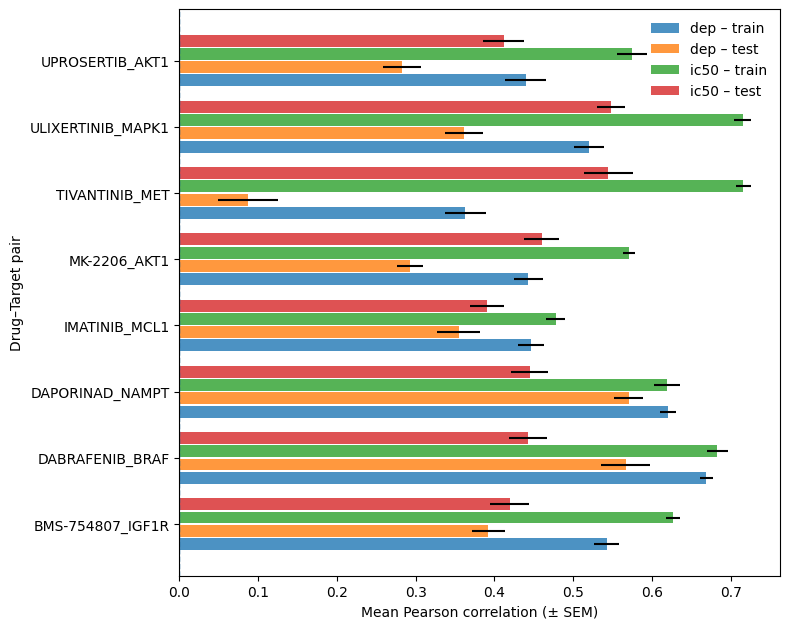

In [18]:
plt.figure(figsize=(8, 0.8 * len(drug_targets)))

for (endpoint, split), offset in offsets.items():
    subset = agg[
        (agg["endpoint"] == endpoint) &
        (agg["set"] == split)
    ]

    y = [
        y_base[list(drug_targets).index(dt)] + offset
        for dt in subset["drug_target"]
    ]

    plt.barh(
        y,
        subset["mean_pearson"],
        xerr=subset["sem_pearson"],
        height=bar_height,
        label=f"{endpoint.replace('_pearson','')} – {split}",
        alpha=0.8
    )

plt.axvline(0, linestyle="--", linewidth=1)

plt.yticks(y_base, drug_targets)
plt.xlabel("Mean Pearson correlation (± SEM)")
plt.ylabel("Drug–Target pair")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig('/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Figs/jointModels_pearsons.pdf', dpi=300, bbox_inches='tight')
plt.show()


####  Gene importance Joint vs Ind models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
from scipy.stats import pearsonr, spearmanr
%matplotlib inline

In [3]:
joint_instances_dir = '/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Models/optuna_models'
drug_target_list = [
    "UPROSERTIB_AKT1",
    "ULIXERTINIB_MAPK1",
    "TIVANTINIB_MET",
    "MK-2206_AKT1",
    "IMATINIB_MCL1",
    "DABRAFENIB_BRAF",
    "BMS-754807_IGF1R",
    "AZD8931_ERBB2",
    "DAPORINAD_NAMPT", "ERLOTINIB_EGFR"
]
models = [
    f for f in os.listdir(joint_instances_dir)
    if f.endswith(".pkl")
    and "Ind" not in f
    and any(dt in f for dt in drug_target_list)
]

len(models)


11

In [4]:
models

['IMATINIB_MCL1_forgeModel_optuna100.pkl',
 'MK-2206_AKT1_forgeModel_optuna100.pkl',
 'ULIXERTINIB_MAPK1_forgeModel_optuna100.pkl',
 'AZD8931_ERBB2_forgeModel_optuna100.pkl',
 'ERLOTINIB_EGFR_forgeModel_optuna100.pkl',
 'DAPORINAD_NAMPT_forgeModel_optuna100_2.pkl',
 'DAPORINAD_NAMPT_forgeModel_optuna100.pkl',
 'BMS-754807_IGF1R_forgeModel_optuna100.pkl',
 'UPROSERTIB_AKT1_forgeModel_optuna100.pkl',
 'TIVANTINIB_MET_forgeModel_optuna100.pkl',
 'DABRAFENIB_BRAF_forgeModel_optuna100.pkl']

In [5]:
ind_models_dir = '/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Models/combined_ind_models'
ind_models = [
    f for f in os.listdir(ind_models_dir)
    if f.endswith(".pkl")
]
len(ind_models)

15

In [6]:
ind_models

['IMATINIB_MCL1_independentModel_optuna_09012026.pkl',
 'TIVANTINIB_MET_independentModel_optuna_09012026.pkl',
 'ULIXERTINIB_MAPK3_independentModel_optuna_09012026.pkl',
 'MK-2206_AKT1_independentModel_optuna_09012026.pkl',
 'DABRAFENIB_BRAF_independentModel_optuna_09012026.pkl',
 'UPROSERTIB_AKT3_independentModel_optuna_09012026.pkl',
 'UPROSERTIB_AKT1_independentModel_optuna_09012026.pkl',
 'ERLOTINIB_EGFR_independentModel_optuna_09012026.pkl',
 'BMS-754807_IGF1R_independentModel_optuna_09012026.pkl',
 'DAPORINAD_NAMPT_independentModel_optuna_09012026.pkl',
 'IMATINIB_PDGFRB_independentModel_optuna_09012026.pkl',
 'MK-2206_AKT3_independentModel_optuna_09012026.pkl',
 'ULIXERTINIB_MAPK1_independentModel_optuna_09012026.pkl',
 'AZD8931_ERBB2_independentModel_optuna_09012026.pkl',
 'BMS-754807_INSR_independentModel_optuna_09012026.pkl']

In [7]:
seed_instance_used = 198716

In [8]:
missing_ind_models = [
    dt for dt in drug_target_list
    if not any(m.startswith(dt) for m in ind_models)
]

len(missing_ind_models)

0

In [9]:
from forge_ind_model_combined_optuna import IndividualFORGE as forge_ind

/home/sreeramp/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
from forge_class_instance3 import FORGE as forge_joint

In [11]:
optuna_joint_models_path = '/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Models/optuna_models'

In [12]:
dep_path = "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/Fresh_FORGE/Data/Dep.csv"
ic50_path = "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/Fresh_FORGE/Data/Creammist_common_ic50.csv"
exp_path = "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/Fresh_FORGE/Data/Exp.csv"

In [12]:
import gc

In [13]:
for drug_target in missing_ind_models:
  drug, target = drug_target.split('_')
  print(f'Creating new Ind model for {drug_target} pair..')
  joint_model_path = os.path.join(optuna_joint_models_path, f'{drug_target}_forgeModel_optuna100.pkl')
  if os.path.exists(joint_model_path):
    joint_model = forge_joint.load_forge(path=joint_model_path)
  else:
    print('Joint model not found for:', drug_target)
    continue
  train_ids, test_ids, hcg_list = joint_model.train_cellLines, joint_model.test_cellLines, joint_model.hcg_list

  ind_model_opt = forge_ind(exp_path=exp_path, dep_path=dep_path, ic50_path=ic50_path,
                            drug = drug, target=target, train_ids=train_ids, test_ids=test_ids,
                            log_file=os.path.join(ind_models_dir, f'{drug_target}_indModel.log'),
                            overwrite=True, hcg_list=hcg_list)
  ind_model_path = os.path.join(ind_models_dir, f'{drug_target}_independentModel_optuna_09012026.pkl')
  ind_model_opt.runPipeline(n_splits=5, seed_val=seed_instance_used, tuning_epochs=500, training_epochs=5000,
                    optuna_trials=100, model_path=ind_model_path)
  print(f'Model training completed for {drug_target}..saved at: {ind_model_path}')
  del joint_model
  gc.collect()
  

Creating new Ind model for UPROSERTIB_AKT1 pair..


[I 2026-01-11 12:38:19,817] A new study created in RDB with name: UPROSERTIB_AKT1_IndModel_dep
[I 2026-01-11 12:38:21,751] Trial 0 finished with value: 0.02584374022825691 and parameters: {'latent_dim': 35, 'learning_rate': 0.001132644097983186, 'lambda': 0.0008263770784655651}. Best is trial 0 with value: 0.02584374022825691.
[I 2026-01-11 12:38:23,502] Trial 1 finished with value: 0.025854647949951015 and parameters: {'latent_dim': 35, 'learning_rate': 0.002481478091508811, 'lambda': 0.0005251368828052419}. Best is trial 0 with value: 0.02584374022825691.
[I 2026-01-11 12:38:24,137] Trial 2 finished with value: 0.027246382191386066 and parameters: {'latent_dim': 10, 'learning_rate': 0.0018611855590001892, 'lambda': 0.007763055250927162}. Best is trial 0 with value: 0.02584374022825691.
[I 2026-01-11 12:38:27,329] Trial 3 finished with value: 0.025191153105578755 and parameters: {'latent_dim': 50, 'learning_rate': 0.0003430643875808348, 'lambda': 0.05087336719883402}. Best is trial 3 

Model training completed for UPROSERTIB_AKT1..saved at: /home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Models/combined_ind_models/UPROSERTIB_AKT1_independentModel_optuna_09012026.pkl
Creating new Ind model for ULIXERTINIB_MAPK1 pair..


[I 2026-01-11 12:44:51,861] A new study created in RDB with name: ULIXERTINIB_MAPK1_IndModel_dep
[I 2026-01-11 12:44:53,648] Trial 0 finished with value: 0.06436762076444714 and parameters: {'latent_dim': 35, 'learning_rate': 0.001132644097983186, 'lambda': 0.0008263770784655651}. Best is trial 0 with value: 0.06436762076444714.
[I 2026-01-11 12:44:55,348] Trial 1 finished with value: 0.06381550276147338 and parameters: {'latent_dim': 35, 'learning_rate': 0.002481478091508811, 'lambda': 0.0005251368828052419}. Best is trial 1 with value: 0.06381550276147338.
[I 2026-01-11 12:44:55,936] Trial 2 finished with value: 0.06965238205221864 and parameters: {'latent_dim': 10, 'learning_rate': 0.0018611855590001892, 'lambda': 0.007763055250927162}. Best is trial 1 with value: 0.06381550276147338.
[I 2026-01-11 12:44:59,041] Trial 3 finished with value: 0.0592604759102046 and parameters: {'latent_dim': 50, 'learning_rate': 0.0003430643875808348, 'lambda': 0.05087336719883402}. Best is trial 3 wi

Model training completed for ULIXERTINIB_MAPK1..saved at: /home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Models/combined_ind_models/ULIXERTINIB_MAPK1_independentModel_optuna_09012026.pkl
Creating new Ind model for MK-2206_AKT1 pair..


...

Model training completed for IMATINIB_MCL1..saved at: /home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Models/combined_ind_models/IMATINIB_MCL1_independentModel_optuna_09012026.pkl
Creating new Ind model for BMS-754807_IGF1R pair..


[I 2026-01-11 13:10:01,838] A new study created in RDB with name: BMS-754807_IGF1R_IndModel_dep
[I 2026-01-11 13:10:04,195] Trial 0 finished with value: 0.06556263942216065 and parameters: {'latent_dim': 35, 'learning_rate': 0.001132644097983186, 'lambda': 0.0008263770784655651}. Best is trial 0 with value: 0.06556263942216065.
[I 2026-01-11 13:10:06,476] Trial 1 finished with value: 0.06585530667056164 and parameters: {'latent_dim': 35, 'learning_rate': 0.002481478091508811, 'lambda': 0.0005251368828052419}. Best is trial 0 with value: 0.06556263942216065.
[I 2026-01-11 13:10:07,190] Trial 2 finished with value: 0.07175252570808456 and parameters: {'latent_dim': 10, 'learning_rate': 0.0018611855590001892, 'lambda': 0.007763055250927162}. Best is trial 0 with value: 0.06556263942216065.
[I 2026-01-11 13:10:11,301] Trial 3 finished with value: 0.06744021159297774 and parameters: {'latent_dim': 50, 'learning_rate': 0.0003430643875808348, 'lambda': 0.05087336719883402}. Best is trial 0 wi

Model training completed for BMS-754807_IGF1R..saved at: /home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Models/combined_ind_models/BMS-754807_IGF1R_independentModel_optuna_09012026.pkl
Creating new Ind model for AZD8931_ERBB2 pair..


[I 2026-01-11 13:18:49,469] A new study created in RDB with name: AZD8931_ERBB2_IndModel_dep
[I 2026-01-11 13:18:51,168] Trial 0 finished with value: 0.06333846819845901 and parameters: {'latent_dim': 35, 'learning_rate': 0.001132644097983186, 'lambda': 0.0008263770784655651}. Best is trial 0 with value: 0.06333846819845901.
[I 2026-01-11 13:18:52,870] Trial 1 finished with value: 0.06492884102493476 and parameters: {'latent_dim': 35, 'learning_rate': 0.002481478091508811, 'lambda': 0.0005251368828052419}. Best is trial 0 with value: 0.06333846819845901.
[I 2026-01-11 13:18:53,408] Trial 2 finished with value: 0.062236223713677576 and parameters: {'latent_dim': 10, 'learning_rate': 0.0018611855590001892, 'lambda': 0.007763055250927162}. Best is trial 2 with value: 0.062236223713677576.
[I 2026-01-11 13:18:56,550] Trial 3 finished with value: 0.06615004818037667 and parameters: {'latent_dim': 50, 'learning_rate': 0.0003430643875808348, 'lambda': 0.05087336719883402}. Best is trial 2 wit

Model training completed for AZD8931_ERBB2..saved at: /home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Models/combined_ind_models/AZD8931_ERBB2_independentModel_optuna_09012026.pkl


In [13]:
ind_models_dir = '/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Models/combined_ind_models'
ind_models = [
    f for f in os.listdir(ind_models_dir)
    if f.endswith(".pkl")
    and "independentModel" in f
    and any(dt in f for dt in drug_target_list)
]

len(ind_models)

10

#### Gene imp plot

In [15]:
# new_drug_target = 
# pearsons_df2 = pd.DataFrame(index = drug_target_list, columns = ['joint', 'ind'])
for drug_target in ['DABRAFENIB_BRAF']:
  ind_model_path = os.path.join(ind_models_dir, f'{drug_target}_independentModel_optuna_09012026.pkl')
  joint_model_path = os.path.join(joint_instances_dir, f'{drug_target}_forgeModel_optuna100.pkl')
  joint_forge = forge_joint.load_forge(path=joint_model_path)
  with open(ind_model_path, 'rb') as f:
    ind_forge = pickle.load(f)
  gene_inf_dep_ind = ind_forge.W_dep @ ind_forge.hD
  gene_inf_ic50_ind = (ind_forge.W_ic50 @ ind_forge.hI) * -1 # negative IC50 imp
  gene_inf_dep_joint = joint_forge.W @ joint_forge.hD
  gene_inf_ic50_joint = (joint_forge.W @ joint_forge.hI) * -1 
  pearson_corr_ind, _ = pearsonr(x=gene_inf_ic50_ind, y = gene_inf_dep_ind)
  pearson_corr_joint, _ = pearsonr(x=gene_inf_ic50_joint, y = gene_inf_dep_joint)
  ind_model_df = pd.DataFrame({'dep_inf': gene_inf_dep_ind.flatten(), 'ic50_inf': gene_inf_ic50_ind.flatten()}, index=ind_forge.hcg_list)
  joint_model_df = pd.DataFrame({'dep_inf': gene_inf_dep_joint.flatten(), 'ic50_inf': gene_inf_ic50_joint.flatten()}, index=ind_forge.hcg_list)

In [18]:
ind_model_df['combined'] = ind_model_df['dep_inf'] - ind_model_df['ic50_inf']
joint_model_df['combined'] = joint_model_df['dep_inf'] - joint_model_df['ic50_inf']

In [22]:
from adjustText import adjust_text
from scipy.stats import pearsonr, spearmanr, kendalltau
from sklearn.metrics import r2_score, mean_absolute_error

# === Updated Plotting Function ===
def plot_gene_influence_scatter(influence_df, top_n=20, mode='Ind', model='EGFR_ERLOTINIB'):
    df_scaled = influence_df.copy()
    
    # Z-score scaling
    #for col in df_scaled.columns:
    #   df_scaled[col] = (df_scaled[col] - df_scaled[col].mean()) / df_scaled[col].std()

    # Get top/bottom genes by total influence
    sorted_genes = df_scaled.sort_values("combined", ascending=False)
    top_genes = sorted_genes.head(top_n)
    bottom_genes = sorted_genes.tail(top_n)
    key_genes_df = pd.concat([top_genes, bottom_genes])
    all_key_genes = list(key_genes_df.index)
    with open(f'/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Data/keyGenes_{mode}_{model}_imp.txt', 'w') as f:
        f.write('\n'.join(all_key_genes))
    # === Scatter plot setup
    fig, ax = plt.subplots(figsize=(11, 11))
    # === Rasterize background points (non-key genes)
    # Mask out key genes
    non_key_genes_df = df_scaled.drop(key_genes_df.index)
    sns.set_theme(style="ticks")  # or "white" or "ticks"


    # Plot background genes in grey
    sns.scatterplot(
        data=non_key_genes_df, x="ic50_inf", y="dep_inf",
        alpha= 0.9, ax=ax, rasterized=True,
        color='grey', edgecolor='black', linewidth=0.15, 
    )

    # Highlight top & bottom genes
    # === Top/bottom genes (keep editable/vector)
    sns.scatterplot(
        data=key_genes_df, x="ic50_inf", y="dep_inf",
        hue=key_genes_df.index, alpha = 1, palette="Set2" , s=80, legend=False, ax=ax,
        rasterized=False  # <== key part!
    )

    # Annotate key genes
    texts = [ax.text(row["ic50_inf"], row["dep_inf"], gene, fontsize=12)
             for gene, row in key_genes_df.iterrows()]
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="->", color='gray', lw=0.5))

    # Axes styling
    ax.set_title("Gene Influence on Model Predictions", fontsize=14)
    ax.set_xlabel("IC50 Effect (Sensitivity)", fontsize=14)
    ax.set_ylabel("Dependency Effect (Essentiality)", fontsize=14)
    ax.axhline(0, ls='--', color='grey')
    ax.axvline(0, ls='--', color='grey')
    
    # === Compute Metrics
    x = df_scaled["ic50_inf"].values
    y = df_scaled["dep_inf"].values
    pearson_corr, pearson_p = pearsonr(x, y)
    spearman_corr, spearman_p = spearmanr(x, y)
    kendall_corr, kendall_p = kendalltau(x, y)
    r2 = r2_score(x, y)
    mae = mean_absolute_error(x, y)

    # === Add metrics box
    metrics_text = (
        f"Pearson r:   {pearson_corr:.2f} (p={pearson_p:.1e})\n"
        f"Spearman ρ:  {spearman_corr:.2f} (p={spearman_p:.1e})\n"
        #f"Kendall τ:   {kendall_corr:.2f} (p={kendall_p:.1e})\n"
        f"R² Score:    {r2:.2f}\n"
        f"MAE:         {mae:.2f}"
    )
    ax.text(0.05, 0.95, metrics_text,
            transform=ax.transAxes,
            fontsize=12,
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=1))

    # Despine top and right spines
    ax.grid(False) 
    sns.despine(top=True, right=True)
    # Set color and linewidth for axes spines (left and bottom)
    
    # === Add this block ===
    ax.tick_params(axis='both', which='both', length=8, width=2, direction='out', color='black')
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')
    
    plt.tight_layout()
    
    
    # === Save figure as PDF ===
    plt.savefig(f'/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Figs/{model}_geneImp_Plot_{mode}Model.pdf', dpi=300, bbox_inches = 'tight')
    #plt.savefig("/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/Figures_latent/ablation_study_noise/gene_influence_plot_ind_model.pdf", format="pdf", dpi=600, bbox_inches="tight")
    plt.show()




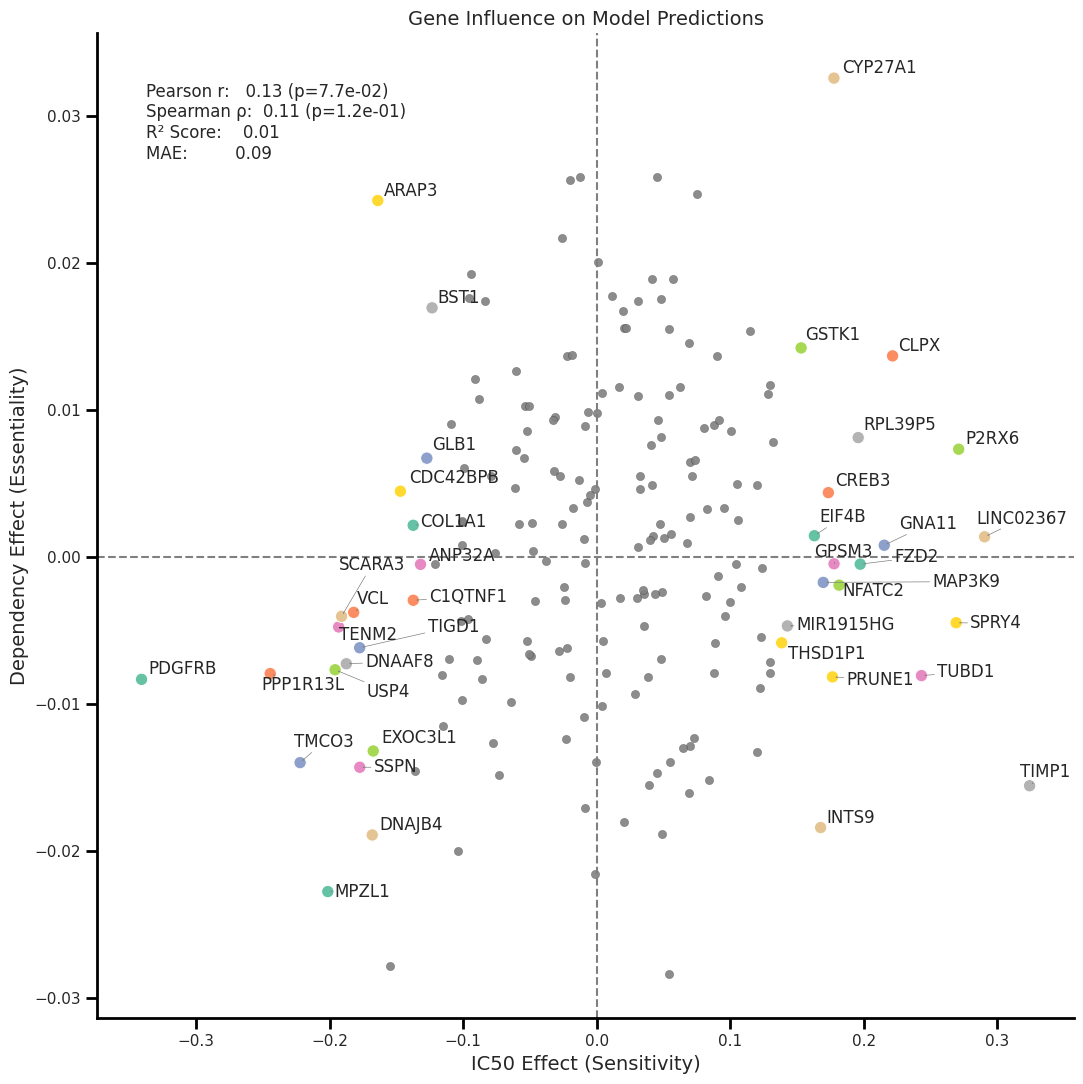

In [23]:
plot_gene_influence_scatter(influence_df=ind_model_df, top_n=20, mode='Ind', model='DABRAFENIB_BRAF')

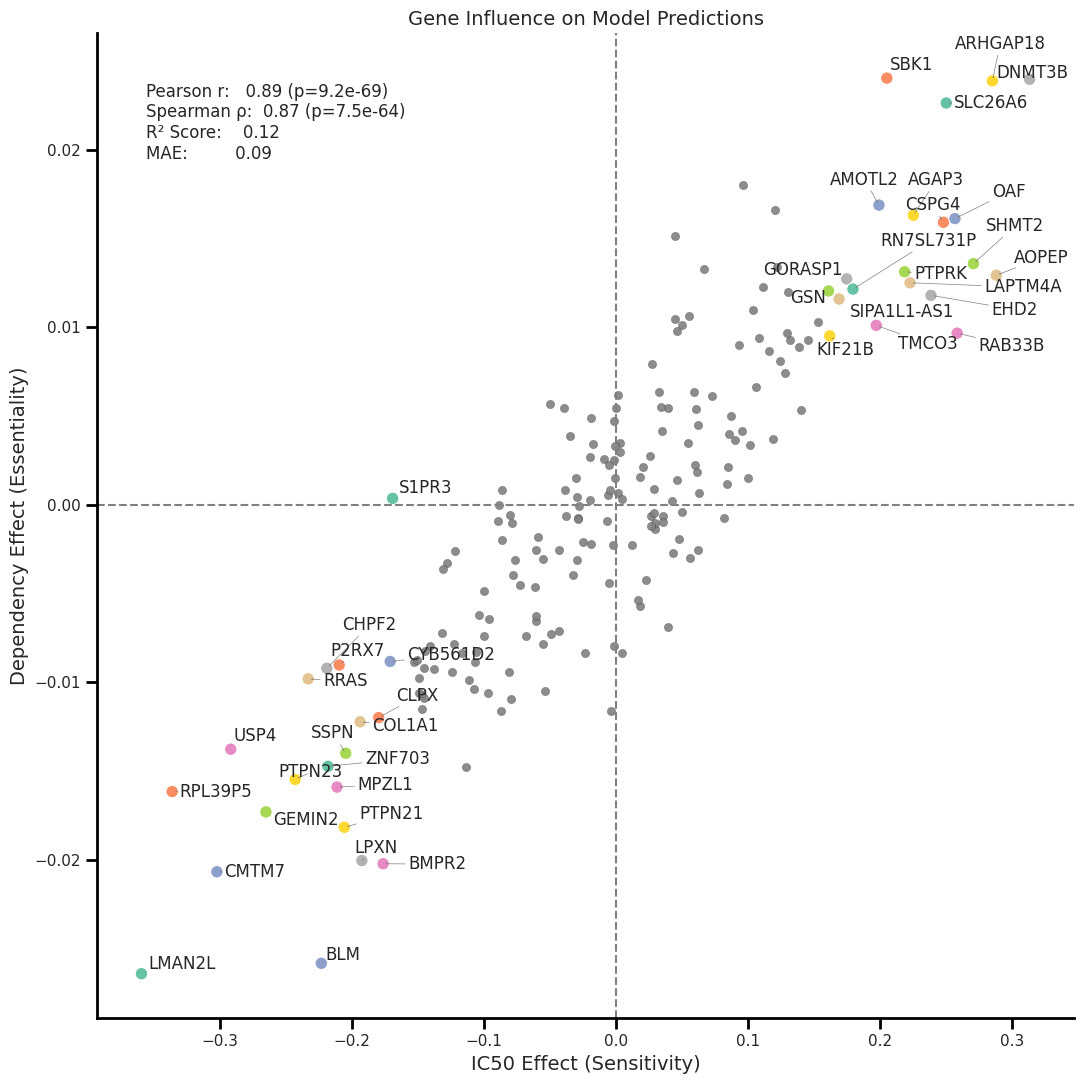

In [24]:
plot_gene_influence_scatter(influence_df=joint_model_df, top_n=20, mode='Joint', model='DABRAFENIB_BRAF')

In [18]:
pearsons_df = pd.DataFrame(index = drug_target_list, columns = ['joint', 'ind'])
for drug_target in drug_target_list:
  ind_model_path = os.path.join(ind_models_dir, f'{drug_target}_independentModel_optuna_09012026.pkl')
  joint_model_path = os.path.join(joint_instances_dir, f'{drug_target}_forgeModel_optuna100.pkl')
  joint_forge = forge_joint.load_forge(path=joint_model_path)
  with open(ind_model_path, 'rb') as f:
    ind_forge = pickle.load(f)
  gene_inf_dep_ind = ind_forge.W_dep @ ind_forge.hD
  gene_inf_ic50_ind = (ind_forge.W_ic50 @ ind_forge.hI) * -1 # negative IC50 imp
  gene_inf_dep_joint = joint_forge.W @ joint_forge.hD
  gene_inf_ic50_joint = (joint_forge.W @ joint_forge.hI) * -1 
  pearson_corr_ind, _ = pearsonr(x=gene_inf_ic50_ind, y = gene_inf_dep_ind)
  pearson_corr_joint, _ = pearsonr(x=gene_inf_ic50_joint, y = gene_inf_dep_joint)
  pearsons_df.loc[drug_target, 'ind'] = pearson_corr_ind
  pearsons_df.loc[drug_target, 'joint'] = pearson_corr_joint

In [19]:
pearsons_df.head()

,joint,ind
UPROSERTIB_AKT1,0.48040935202070373,0.15264645637184757
ULIXERTINIB_MAPK1,0.598312057568869,0.13539265462248629
TIVANTINIB_MET,0.08202819167302496,0.3887009508592296
MK-2206_AKT1,0.36863150141513057,0.12294341491699627
IMATINIB_MCL1,0.0508660219703578,-0.1798193134494693


In [20]:
# use t-test to compare them
from scipy.stats import levene, ttest_rel

levene_t, levene_p = levene(pearsons_df['joint'], pearsons_df['ind'])
print(levene_p)
eq_var = levene_p < 0.05 # if true not equal variances
print(eq_var)

0.1032825581317663
False


In [22]:
pearsons_df['joint'] = pd.to_numeric(pearsons_df['joint'], errors='coerce')
pearsons_df['ind']   = pd.to_numeric(pearsons_df['ind'], errors='coerce')
df_clean = pearsons_df[['joint', 'ind']].dropna()


In [25]:
pearsons_df[['joint', 'ind']].applymap(type).nunique()

/tmp/ipykernel_2647177/1544769134.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pearsons_df[['joint', 'ind']].applymap(type).nunique()


joint    1
ind      1
dtype: int64

In [92]:
pearsons_df.to_csv('/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Data/pearson_geneImp_corrs_joint_ind.csv', index=True)

In [25]:
pearsons_df = pd.read_csv('/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Data/pearson_geneImp_corrs_joint_ind.csv', index_col=0)

In [26]:
pearsons_df['joint'] = pearsons_df['joint'].apply(lambda x: x.item())
pearsons_df['ind']   = pearsons_df['ind'].apply(lambda x: x.item())

AttributeError: 'float' object has no attribute 'item'

In [27]:
df_clean = pearsons_df[['joint', 'ind']].dropna()
df_clean.head()

,joint,ind
UPROSERTIB_AKT1,0.480409,0.152646
ULIXERTINIB_MAPK1,0.598312,0.135393
TIVANTINIB_MET,0.082028,0.388701
MK-2206_AKT1,0.368632,0.122943
IMATINIB_MCL1,0.050866,-0.179819


In [29]:
from scipy.stats import ttest_rel

In [30]:
t_stat, t_p = ttest_rel(
    a=df_clean['joint'].values,
    b=df_clean['ind'].values,
    alternative='greater'
)

t_stat, t_p

(np.float64(2.0247763764220026), np.float64(0.03874126380922016))

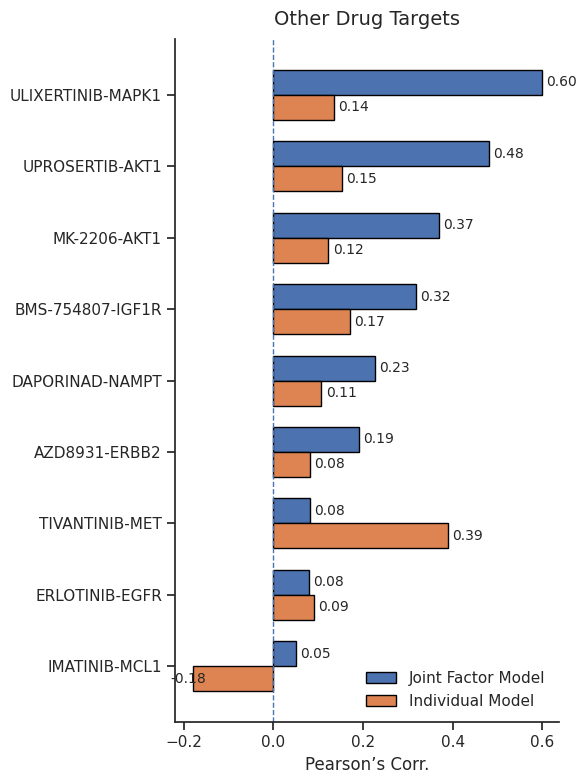

In [31]:
df = df_clean.copy()
df = df.sort_values('joint')

labels = df.index.str.replace('_', '-', regex=False)
y = np.arange(len(df))

# Bar settings
bar_height = 0.35
offset = bar_height / 2

fig, ax = plt.subplots(figsize=(6, 8))

# Horizontal bars
ax.barh(
    y + offset,
    df['joint'],
    height=bar_height,
    label='Joint Factor Model',
    edgecolor='black'
)

ax.barh(
    y - offset,
    df['ind'],
    height=bar_height,
    label='Individual Model',
    edgecolor='black'
)

# Vertical reference line at 0
ax.axvline(0, linestyle='--', linewidth=1)

# Y-axis labels
ax.set_yticks(y)
ax.set_yticklabels(labels)

# Axis labels and title
ax.set_xlabel("Pearson’s Corr.", fontsize=12)
ax.set_title("Other Drug Targets", fontsize=14, pad=10)

# Annotate values
for i, (j, ind) in enumerate(zip(df['joint'], df['ind'])):
    ax.text(j + 0.01, i + offset, f"{j:.2f}", va='center', fontsize=10)
    ax.text(ind + 0.01 if ind >= 0 else ind - 0.05,
            i - offset, f"{ind:.2f}", va='center', fontsize=10)

# Legend
ax.legend(frameon=False, loc='lower right')

# Clean look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Figs/correlation_geneInfluences_new.pdf', dpi=300, bbox_inches = 'tight')
plt.show()


#### Fig 2c EGFR y vs benefit score correlation

In [37]:
drug_target = 'ERLOTINIB_EGFR'
joint_models = [i for i in os.listdir(joint_instances_dir) if i.startswith(drug_target) and i.endswith('.pkl')]
joint_models.extend([i for i in os.listdir('/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Models/multiSeed_optuna') 
                     if i.startswith(drug_target) and i.endswith('.pkl')])
len(joint_models)

10

In [38]:
ind_models = [i for i in os.listdir('/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Models/combined_ind_models') 
              if i.startswith(drug_target) and i.endswith('.pkl')]
ind_models.extend([i for i in os.listdir('/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Models/multiSeed_optuna_indModels') 
              if i.startswith(drug_target) and i.endswith('.pkl')])
len(ind_models)

10

In [46]:
joint_models

['ERLOTINIB_EGFR_forgeModel_optuna100.pkl',
 'ERLOTINIB_EGFR_forgeModel_optuna100_161287.pkl',
 'ERLOTINIB_EGFR_forgeModel_optuna100_586231.pkl',
 'ERLOTINIB_EGFR_forgeModel_optuna100_321456.pkl',
 'ERLOTINIB_EGFR_forgeModel_optuna100_227745.pkl',
 'ERLOTINIB_EGFR_forgeModel_optuna100_23698.pkl',
 'ERLOTINIB_EGFR_forgeModel_optuna100_228796.pkl',
 'ERLOTINIB_EGFR_forgeModel_optuna100_42.pkl',
 'ERLOTINIB_EGFR_forgeModel_optuna100_12587.pkl',
 'ERLOTINIB_EGFR_forgeModel_optuna100_11111222.pkl']

In [45]:
ind_models

['ERLOTINIB_EGFR_independentModel_optuna_09012026.pkl',
 'ERLOTINIB_EGFR_independentModel_optuna_161287.pkl',
 'ERLOTINIB_EGFR_independentModel_optuna_11111222.pkl',
 'ERLOTINIB_EGFR_independentModel_optuna_227745.pkl',
 'ERLOTINIB_EGFR_independentModel_optuna_228796.pkl',
 'ERLOTINIB_EGFR_independentModel_optuna_321456.pkl',
 'ERLOTINIB_EGFR_independentModel_optuna_23698.pkl',
 'ERLOTINIB_EGFR_independentModel_optuna_586231.pkl',
 'ERLOTINIB_EGFR_independentModel_optuna_42.pkl',
 'ERLOTINIB_EGFR_independentModel_optuna_12587.pkl']

In [51]:
exp_data = pd.read_csv(exp_path, header = 0, index_col=0)
exp_data.head()

,A1BG,A1BG-AS1,A2M,A4GALT,AAAS,AACS,AADAT,AAGAB,AAK1,AAMDC,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
StrippedCellLineName,,,,,,,,,,,,,,,,,,,,,
127399,1.335851,2.837184,-0.475762,3.522372,5.289224,5.436261,1.912285,6.170977,5.486915,5.258901,...,6.255815,7.125433,0.970038,3.911810,3.513628,3.671321,5.387186,7.657886,4.690012,5.671180
143B,0.505021,1.146315,4.020641,2.191379,5.726666,3.992820,3.975156,6.908841,4.667542,2.956823,...,7.219736,7.134179,1.487684,4.076379,4.290047,3.913427,4.413880,7.452491,5.690861,6.489629
170MGBA,-6.343651,-1.951334,7.934532,3.568739,4.676171,4.810112,2.668508,6.323091,6.443912,3.275346,...,5.663259,4.028126,2.966962,4.290252,4.614660,-7.928613,6.486930,7.582614,6.399150,7.430827
22RV1,-0.050892,2.802209,2.974042,-2.257672,6.130935,6.428204,3.251642,6.020554,6.088325,0.637311,...,6.658125,7.350443,1.131819,3.456761,4.554439,-1.247825,5.552063,4.451671,5.854928,5.957179
2313287,-4.772263,-1.602338,-4.772263,1.264826,5.211839,4.931832,-4.241749,6.394806,5.462554,2.045076,...,6.162984,6.500690,1.941982,4.451470,4.655631,-3.854726,5.514551,5.788176,5.886246,6.400234


In [60]:
dep_path = "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/Fresh_FORGE/Data/Dep.csv"
ic50_path = "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/Fresh_FORGE/Data/Creammist_common_ic50.csv"

In [61]:
dep_data = pd.read_csv(dep_path, header=0, index_col = 0)
ic50_data = pd.read_csv(ic50_path, header = 0, index_col = 0)
ic50_data = ic50_data.T

In [64]:
benefit_score_corrs = pd.DataFrame(columns = ['ind_ic50', 'ind_dep', 'joint_ic50', 'joint_dep'])
seed_vals = []
JOINT_FALLBACK = (
    '/home/sreeramp/cancer_dependency_project/nilabja/'
    'Approach3_Latent_factor/git_repo/Models/'
    'optuna_models/ERLOTINIB_EGFR_forgeModel_optuna100.pkl'
)

IND_FALLBACK = (
    '/home/sreeramp/cancer_dependency_project/nilabja/'
    'Approach3_Latent_factor/git_repo/Models/'
    'combined_ind_models/ERLOTINIB_EGFR_independentModel_optuna_09012026.pkl'
)

IND_DIRS = [
    '/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Models/combined_ind_models',
    '/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Models/multiSeed_optuna_indModels'
]

for joint_model_file in joint_models:

    # -------------------------------
    # Resolve JOINT model path
    # -------------------------------
    joint_model_path = None

    for base in [
        joint_instances_dir,
        '/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Models/multiSeed_optuna'
    ]:
        candidate = os.path.join(base, joint_model_file)
        if os.path.exists(candidate):
            joint_model_path = candidate
            break

    if joint_model_path is None:
        joint_model_path = JOINT_FALLBACK

    # -------------------------------
    # Extract seed
    # -------------------------------
    seed_val = joint_model_file.split('_')[-1].replace('.pkl', '')

    # -------------------------------
    # Resolve IND model path
    # -------------------------------
    matched_files = [i for i in ind_models if i.endswith(f'{seed_val}.pkl')]

    ind_model_path = None

    if matched_files:
        ind_file = matched_files[0]  # take first match

        for base in IND_DIRS:
            candidate = os.path.join(base, ind_file)
            if os.path.exists(candidate):
                ind_model_path = candidate
                break

    if ind_model_path is None:
        ind_model_path = IND_FALLBACK

    # -------------------------------
    # Debug output
    # -------------------------------
    print("\n".join([
        f"Joint model file : {joint_model_file}",
        f"Seed            : {seed_val}",
        f"Joint path      : {joint_model_path}",
        f"Ind path        : {ind_model_path}",
    ]))
    
    joint_forge = forge_joint.load_forge(path=joint_model_path)
    with open(ind_model_path, 'rb') as f:
      ind_model = pickle.load(f)
    CELL_LINES = joint_forge.train_cellLines[:]
    CELL_LINES.extend(joint_forge.test_cellLines)
    scaled_exp = ((joint_forge.exp_hcg.loc[CELL_LINES] - joint_forge.mean_exp) / joint_forge.std_exp).values
    ic50_centered = (ic50_data.loc[CELL_LINES, 'ERLOTINIB'].values - joint_forge.mean_ic50).reshape(-1,1)
    dep_centered = (dep_data.loc[CELL_LINES, 'EGFR'].values - joint_forge.mean_dep).reshape(-1,1)
    print(scaled_exp.shape, ic50_centered.shape, dep_centered.shape)
    gene_inf_dep_ind = ind_model.W_dep @ ind_model.hD
    gene_inf_ic50_ind = ind_model.W_ic50 @ ind_model.hI
    gene_inf_dep_joint = joint_forge.W @ joint_forge.hD
    gene_inf_ic50_joint = joint_forge.W @ joint_forge.hI
    gene_inf_combined_ind = gene_inf_dep_ind - gene_inf_ic50_ind
    gene_inf_combined_joint = gene_inf_dep_joint - gene_inf_ic50_joint
    scaled_inf_ind = (gene_inf_combined_ind - np.mean(gene_inf_combined_ind)) / np.std(gene_inf_combined_ind)
    scaled_inf_joint = (gene_inf_combined_joint - np.mean(gene_inf_combined_joint)) / np.std(gene_inf_combined_joint)
    benefit_scores_ind = scaled_exp @ scaled_inf_ind
    benefit_scores_joint = scaled_exp @ scaled_inf_joint
    pearson_ind_ic50, _ = pearsonr(x = benefit_scores_ind.flatten(), y = ic50_centered.flatten())
    pearson_joint_ic50, _ = pearsonr(x = benefit_scores_joint.flatten(), y = ic50_centered.flatten())
    pearson_ind_dep, _ = pearsonr(x = benefit_scores_joint.flatten(), y = dep_centered.flatten())
    pearson_joint_dep, _ = pearsonr(x = benefit_scores_joint.flatten(), y = dep_centered.flatten())
    print(f"Ind:   {pearson_ind_ic50:.3f} {pearson_ind_dep:.3f}")
    print(f"Joint: {pearson_joint_ic50:.3f} {pearson_joint_dep:.3f}")
    benefit_score_corrs.loc[seed_val, 'ind_ic50'] = pearson_ind_ic50
    benefit_score_corrs.loc[seed_val, 'ind_dep'] = pearson_ind_dep
    benefit_score_corrs.loc[seed_val, 'joint_ic50'] = pearson_joint_ic50
    benefit_score_corrs.loc[seed_val, 'joint_dep'] = pearson_joint_dep
    print('***' * 30)


Joint model file : ERLOTINIB_EGFR_forgeModel_optuna100.pkl
Seed            : optuna100
Joint path      : /home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Models/optuna_models/ERLOTINIB_EGFR_forgeModel_optuna100.pkl
Ind path        : /home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Models/combined_ind_models/ERLOTINIB_EGFR_independentModel_optuna_09012026.pkl
(687, 201) (687, 1) (687, 1)
Ind:   -0.489 0.355
Joint: -0.491 0.355
******************************************************************************************
Joint model file : ERLOTINIB_EGFR_forgeModel_optuna100_161287.pkl
Seed            : 161287
Joint path      : /home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Models/multiSeed_optuna/ERLOTINIB_EGFR_forgeModel_optuna100_161287.pkl
Ind path        : /home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Models/multiSeed_optuna_indModels/ERLOTINIB_EGFR_in

In [65]:
benefit_score_corrs.head()

,ind_ic50,ind_dep,joint_ic50,joint_dep
optuna100,-0.489404,0.355353,-0.490763,0.355353
161287,-0.078489,0.432273,-0.503036,0.432273
586231,0.339733,0.42202,-0.529398,0.42202
321456,0.189763,0.437503,-0.527375,0.437503
227745,0.14887,0.351273,-0.507114,0.351273


In [79]:
def p_to_star(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'n.s.'

In [80]:
from scipy.stats import sem, ttest_rel

In [83]:
## t test
# benefit_score_corrs['joint_ic50'] = benefit_score_corrs['joint_ic50'].apply(lambda x: x.item())
# benefit_score_corrs['ind_ic50'] = benefit_score_corrs['ind_ic50'].apply(lambda x: x.item())
benefit_score_corrs['joint_dep'] = benefit_score_corrs['joint_dep'].apply(lambda x: x.item())
benefit_score_corrs['ind_dep'] = benefit_score_corrs['ind_dep'].apply(lambda x: x.item())
_, p_ic50 = ttest_rel(a = benefit_score_corrs['joint_ic50'].values, b = benefit_score_corrs['ind_ic50'].values)
_, p_dep = ttest_rel(a = benefit_score_corrs['joint_dep'].values, b = benefit_score_corrs['ind_dep'].values)

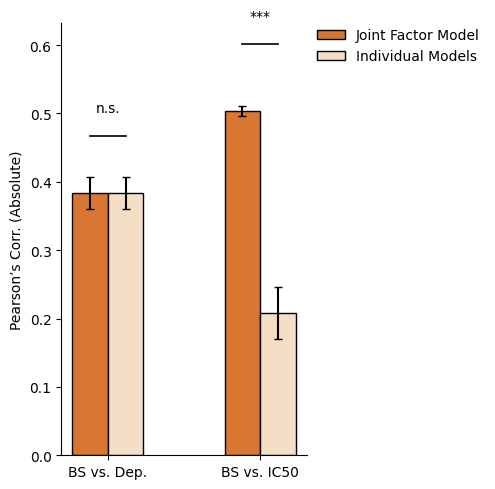

In [90]:
# -------------------------
# Prepare data
# -------------------------
means = {
    'dep': [
        benefit_score_corrs['joint_dep'].abs().mean(),
        benefit_score_corrs['ind_dep'].abs().mean()
    ],
    'ic50': [
        benefit_score_corrs['joint_ic50'].abs().mean(),
        benefit_score_corrs['ind_ic50'].abs().mean()
    ]
}

sems = {
    'dep': [
        benefit_score_corrs['joint_dep'].abs().sem(),
        benefit_score_corrs['ind_dep'].abs().sem()
    ],
    'ic50': [
        benefit_score_corrs['joint_ic50'].abs().sem(),
        benefit_score_corrs['ind_ic50'].abs().sem()
    ]
}

stars = {
    'dep': p_to_star(p_dep),
    'ic50': p_to_star(p_ic50)
}

# -------------------------
# Plot
# -------------------------
fig, ax = plt.subplots(figsize=(6, 5))

x = np.array([0, 1.2])      # group centers
width = 0.28

colors = {
    'joint':  '#D97732',  
    'ind':  '#F4DFC6'     
}

# BS vs Dep
ax.bar(x[0] - width/2, means['dep'][0], width,
       yerr=sems['dep'][0], capsize=3,
       color=colors['joint'], edgecolor='black',
       label='Joint Factor Model')

ax.bar(x[0] + width/2, means['dep'][1], width,
       yerr=sems['dep'][1], capsize=3,
       color=colors['ind'], edgecolor='black',
       label='Individual Models')

# BS vs IC50
ax.bar(x[1] - width/2, means['ic50'][0], width,
       yerr=sems['ic50'][0], capsize=3,
       color=colors['joint'], edgecolor='black')

ax.bar(x[1] + width/2, means['ic50'][1], width,
       yerr=sems['ic50'][1], capsize=3,
       color=colors['ind'], edgecolor='black')

# -------------------------
# Significance lines + text
# -------------------------
def draw_sig(ax, x_center, y, text):
    h = 0.03
    ax.plot([x_center - width/2, x_center + width/2],
            [y, y], lw=1.2, color='black')
    ax.text(x_center, y + h, text,
            ha='center', va='bottom', fontsize=10)

y_dep  = max(means['dep'])  + max(sems['dep'])  + 0.06
y_ic50 = max(means['ic50']) + max(sems['ic50']) + 0.06

draw_sig(ax, x[0], y_dep,  stars['dep'])
draw_sig(ax, x[1], y_ic50, stars['ic50'])

# -------------------------
# Aesthetics
# -------------------------
ax.set_xticks(x)
ax.set_xticklabels(['BS vs. Dep.', 'BS vs. IC50'])
ax.set_ylabel("Pearson’s Corr. (Absolute)")
ax.legend(
    frameon=False,
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig('/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Figs/joint_ind_bs_corrs.pdf', dpi = 300, bbox_inches = 'tight')
plt.show()


In [91]:
benefit_score_corrs.to_csv('/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Data/bs_corrs_ind_joint.csv', index=True)

##### Analyse steiner graph

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, ttest_1samp
%matplotlib inline

In [2]:
rwr_prob = pd.read_csv('/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Data/depMap_RWR_EGFR_probs.csv', header = 0, index_col=0)
rwr_prob.head()

,rwr_prob_EGFR,gene,EGFR_KEGG,FORGE_HCG,gene_imp,logFC,adj.P.Val,depMap_avg_exp,deg_type,top20_prob
TYMS,0.000054,TYMS,no,no,NaN,-0.006422,0.954032,7.040001,non_significant,non_hcg
ARHGEF5,0.000094,ARHGEF5,no,yes,0.763094,-0.241592,0.495908,1.793664,non_significant,low_rwrProb
CDH20,0.000015,CDH20,no,no,NaN,NaN,NaN,NaN,non_significant,non_hcg
LIMS1,0.000015,LIMS1,no,no,NaN,-0.029329,0.713338,6.229401,non_significant,non_hcg
OLIG2,0.000011,OLIG2,no,no,NaN,NaN,NaN,NaN,non_significant,non_hcg


In [4]:
x = rwr_prob['rwr_prob_EGFR'].values

iqr = np.quantile(x, 0.75) - np.quantile(x, 0.25)
iqr = max(iqr, 1e-8)   # numerical floor

z = (x - np.median(x)) / iqr

rwr_prob['log_scaled_rwr'] = np.sign(z) * np.log10(1 + np.abs(z))


In [5]:
df = rwr_prob.copy()

In [98]:
deg_res = pd.read_csv('/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Data/Daporinad_NAMPT_depMap_keyCluster_deg_optuna.csv', header = 0, index_col=0)
deg_res.head()

,logFC,AveExpr,t,P.Value,adj.P.Val,B
DNAH14,-3.712514,2.242108,-11.883910,1.340338e-29,2.183276e-25,55.989020
CRY1,-2.009733,4.484185,-10.886958,1.837192e-25,1.496301e-21,46.751763
KLF11,-2.537320,3.590351,-10.450715,9.949437e-24,5.402212e-20,42.882767
GPHN,-2.269347,4.092406,-9.952211,8.282346e-22,3.372778e-18,38.599142
ZNF74,-1.666681,3.745173,-9.774558,3.857722e-21,1.256769e-17,37.109302


In [6]:
df.head()

,rwr_prob_EGFR,gene,EGFR_KEGG,FORGE_HCG,gene_imp,logFC,adj.P.Val,depMap_avg_exp,deg_type,top20_prob,log_scaled_rwr
TYMS,0.000054,TYMS,no,no,NaN,-0.006422,0.954032,7.040001,non_significant,non_hcg,0.016359
ARHGEF5,0.000094,ARHGEF5,no,yes,0.763094,-0.241592,0.495908,1.793664,non_significant,low_rwrProb,0.152902
CDH20,0.000015,CDH20,no,no,NaN,NaN,NaN,NaN,non_significant,non_hcg,-0.127963
LIMS1,0.000015,LIMS1,no,no,NaN,-0.029329,0.713338,6.229401,non_significant,non_hcg,-0.128035
OLIG2,0.000011,OLIG2,no,no,NaN,NaN,NaN,NaN,non_significant,non_hcg,-0.139658


In [102]:
common_genes = list(set(rwr_prob.index) & set(deg_res.index))
len(common_genes)

1452

In [104]:
df = df.loc[common_genes]
deg_df = deg_res.loc[common_genes]

In [105]:
deg_df.head()

,logFC,AveExpr,t,P.Value,adj.P.Val,B
RIPK4,-1.785087,3.104787,-3.874826,0.000118,0.001430,0.738766
TUBA3D,-0.167883,-1.841985,-0.920387,0.357714,0.554643,-6.125230
LARP1,-0.078218,8.438577,-1.184681,0.236578,0.426428,-5.852796
IDH2,-0.059397,6.134749,-0.333119,0.739152,0.850433,-6.486067
RPL6,-0.083896,9.322571,-1.018236,0.308946,0.505073,-6.032316


In [107]:
deg_df['deg_type'] = np.where(
    deg_df['adj.P.Val'] < 0.05,
    np.where(
        deg_df['logFC'] > 1, 
        'upregulated',
        np.where(
            deg_df['logFC'] < -1, 
            'downregulated',
            'nonsignificant'
        )
    ),
    'nonsignificant'
)


In [108]:
df = pd.merge(left=df, right=deg_df, left_index=True, right_index=True, how='outer')
df.shape

(1452, 12)

In [7]:
df.head()

,rwr_prob_EGFR,gene,EGFR_KEGG,FORGE_HCG,gene_imp,logFC,adj.P.Val,depMap_avg_exp,deg_type,top20_prob,log_scaled_rwr
TYMS,0.000054,TYMS,no,no,NaN,-0.006422,0.954032,7.040001,non_significant,non_hcg,0.016359
ARHGEF5,0.000094,ARHGEF5,no,yes,0.763094,-0.241592,0.495908,1.793664,non_significant,low_rwrProb,0.152902
CDH20,0.000015,CDH20,no,no,NaN,NaN,NaN,NaN,non_significant,non_hcg,-0.127963
LIMS1,0.000015,LIMS1,no,no,NaN,-0.029329,0.713338,6.229401,non_significant,non_hcg,-0.128035
OLIG2,0.000011,OLIG2,no,no,NaN,NaN,NaN,NaN,non_significant,non_hcg,-0.139658


In [8]:
df_long = (
    df
    .melt(
        id_vars=['gene', 'log_scaled_rwr'],
        value_vars=['EGFR_KEGG', 'FORGE_HCG', 'deg_type'],
        var_name='source',
        value_name='membership'
    )
)

In [9]:
df_long['membership'].value_counts()

membership
no                 4672
non_significant    2210
yes                 218
downregulated       161
upregulated          74
Name: count, dtype: int64

In [10]:
def assign_group(row):
    if row['source'] == 'EGFR_KEGG' and row['membership'] == 'yes':
        return 'KEGG'
    if row['source'] == 'FORGE_HCG' and row['membership'] == 'yes':
        return 'FORGE'
    if row['source'] == 'deg_type':
        return row['membership']   # keep all 3 DEG types
    return None

In [11]:
df_long['group'] = df_long.apply(assign_group, axis=1)

In [12]:
df_long.head()

,gene,log_scaled_rwr,source,membership,group
0,TYMS,0.016359,EGFR_KEGG,no,None
1,ARHGEF5,0.152902,EGFR_KEGG,no,None
2,CDH20,-0.127963,EGFR_KEGG,no,None
3,LIMS1,-0.128035,EGFR_KEGG,no,None
4,OLIG2,-0.139658,EGFR_KEGG,no,None


In [13]:
df_long = df_long[df_long['group'].notna()]

In [14]:
df_long['group'].value_counts()

group
non_significant    2210
downregulated       161
FORGE               138
KEGG                 80
upregulated          74
Name: count, dtype: int64

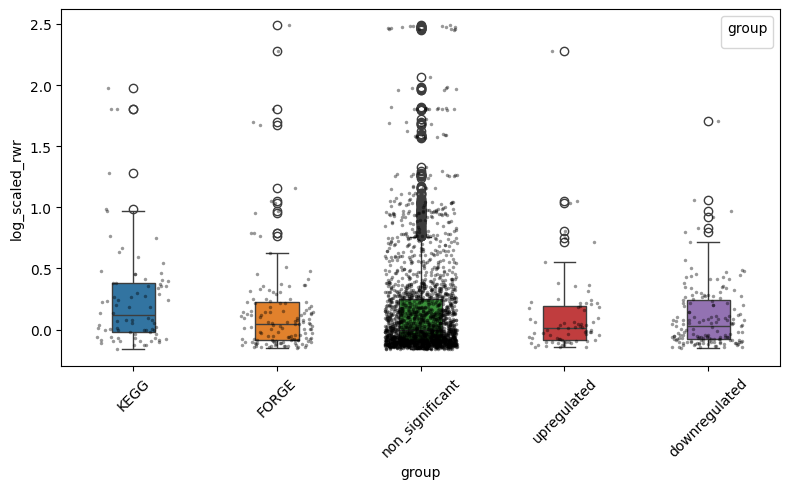

In [15]:
plt.figure(figsize=(8, 5))

# Boxplot
sns.boxplot(
    data=df_long,
    x='group', width = 0.3,
    y='log_scaled_rwr',
    hue='group'
)

# Stripplot (jittered points)
sns.stripplot(
    data=df_long,
    x='group',
    y='log_scaled_rwr',
    color='black',     # keep dots black
    jitter=0.25,
    alpha=0.4,
    size=2.5
)

plt.xticks(rotation=45)
plt.tight_layout()

# Remove duplicate legends (keep only boxplot legend)
handles, labels = plt.gca().get_legend_handles_labels()
n = df_long['group'].nunique()
plt.legend(handles[:n], labels[:n], title='group')
# plt.savefig('/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Figs/rwr_probs_NAMPT.pdf', dpi = 300, bbox_inches = 'tight')
plt.show()


In [16]:
df.head()

,rwr_prob_EGFR,gene,EGFR_KEGG,FORGE_HCG,gene_imp,logFC,adj.P.Val,depMap_avg_exp,deg_type,top20_prob,log_scaled_rwr
TYMS,0.000054,TYMS,no,no,NaN,-0.006422,0.954032,7.040001,non_significant,non_hcg,0.016359
ARHGEF5,0.000094,ARHGEF5,no,yes,0.763094,-0.241592,0.495908,1.793664,non_significant,low_rwrProb,0.152902
CDH20,0.000015,CDH20,no,no,NaN,NaN,NaN,NaN,non_significant,non_hcg,-0.127963
LIMS1,0.000015,LIMS1,no,no,NaN,-0.029329,0.713338,6.229401,non_significant,non_hcg,-0.128035
OLIG2,0.000011,OLIG2,no,no,NaN,NaN,NaN,NaN,non_significant,non_hcg,-0.139658


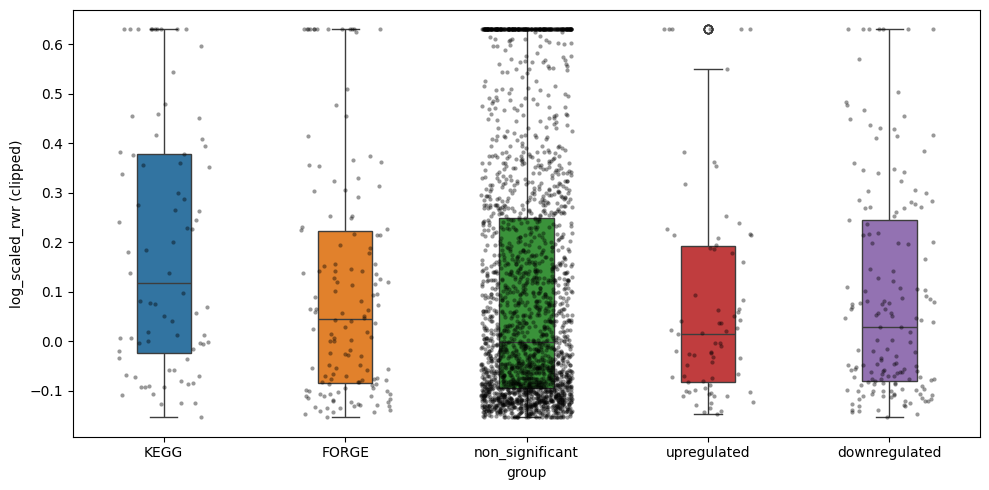

In [18]:
# clip only for plotting
plot_df = df_long.copy()
upper = plot_df['log_scaled_rwr'].quantile(0.9)   # top 2% clipped
lower = plot_df['log_scaled_rwr'].quantile(0.01)

plot_df['log_scaled_rwr_clip'] = plot_df['log_scaled_rwr'].clip(lower, upper)

plt.figure(figsize=(10,5))
sns.boxplot(data=plot_df, x='group', y='log_scaled_rwr_clip', width=0.3, hue='group')
sns.stripplot(
    data=plot_df, x='group', y='log_scaled_rwr_clip',
    jitter=0.25, alpha=0.4, size=3, color='black'
)
plt.ylabel("log_scaled_rwr (clipped)")
plt.tight_layout()
plt.savefig('/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Figs/rwr_probs_EGFR.pdf', dpi = 300, bbox_inches = 'tight')
plt.show()


In [19]:
from scipy.stats import mannwhitneyu

groups = df_long['group'].unique()

pval_mat = pd.DataFrame(
    index=groups,
    columns=groups,
    dtype=float
)

for ref in groups:
    x = df_long.loc[df_long['group'] == ref, 'log_scaled_rwr'].dropna().values
    
    for test in groups:
        if ref == test:
            pval_mat.loc[ref, test] = np.nan
            continue
        
        y = df_long.loc[df_long['group'] == test, 'log_scaled_rwr'].dropna().values
        
        # Mann–Whitney U (two-sided, nonparametric)
        _, pval = mannwhitneyu(x, y, alternative='greater')
        pval_mat.loc[ref, test] = pval


In [20]:
pval_mat

,KEGG,FORGE,non_significant,upregulated,downregulated
KEGG,NaN,0.007400,0.000181,0.002849,0.001814
FORGE,0.992646,NaN,0.208841,0.288074,0.403797
non_significant,0.999819,0.791197,NaN,0.538580,0.691265
upregulated,0.997182,0.712727,0.461491,NaN,0.649988
downregulated,0.998198,0.596723,0.308777,0.350778,NaN


In [21]:
from statsmodels.stats.multitest import multipletests

mask = ~np.isnan(pval_mat.values)
pvals = pval_mat.values[mask]

_, pvals_adj, _, _ = multipletests(pvals, method='fdr_bh')

pval_mat_fdr = pval_mat.copy()
pval_mat_fdr.values[mask] = pvals_adj

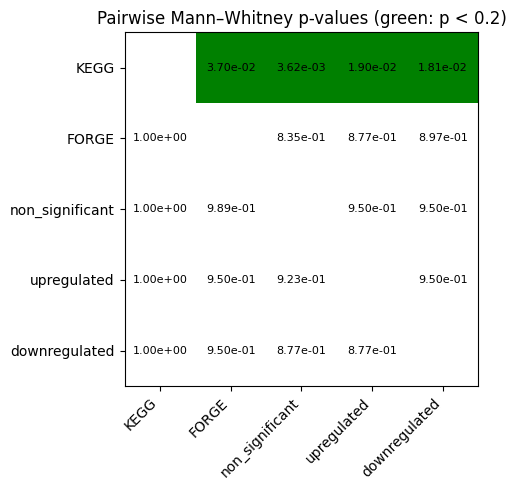

In [22]:
from matplotlib.colors import ListedColormap
# significance mask
sig = (pval_mat_fdr < 0.2).astype(float)

# mask diagonal
np.fill_diagonal(sig.values, np.nan)

# colormap: white = not significant, green = significant
cmap = ListedColormap(['white', 'green'])

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(sig, cmap=cmap, vmin=0, vmax=1)

# ticks
ax.set_xticks(range(len(sig.columns)))
ax.set_yticks(range(len(sig.index)))
ax.set_xticklabels(sig.columns, rotation=45, ha='right')
ax.set_yticklabels(sig.index)

# annotate p-values
for i in range(sig.shape[0]):
    for j in range(sig.shape[1]):
        if not np.isnan(sig.iloc[i, j]):
            ax.text(
                j, i,
                f"{pval_mat_fdr.iloc[i, j]:.2e}",
                ha='center', va='center',
                fontsize=8
            )

ax.set_title('Pairwise Mann–Whitney p-values (green: p < 0.2)')
plt.tight_layout()
plt.show()

In [23]:
rbc_mat = pd.DataFrame(
    index=groups,
    columns=groups,
    dtype=float
)

for ref in groups:
    x = df_long.loc[
        df_long['group'] == ref, 'log_scaled_rwr'
    ].dropna().values

    for test in groups:
        if ref == test:
            rbc_mat.loc[ref, test] = np.nan
            continue

        y = df_long.loc[
            df_long['group'] == test, 'log_scaled_rwr'
        ].dropna().values

        # Mann–Whitney U
        U, _ = mannwhitneyu(x, y, alternative='greater')

        n1 = len(x)
        n2 = len(y)

        # Rank-biserial correlation
        rbc = 1 - (2 * U) / (n1 * n2)
        rbc_mat.loc[ref, test] = rbc

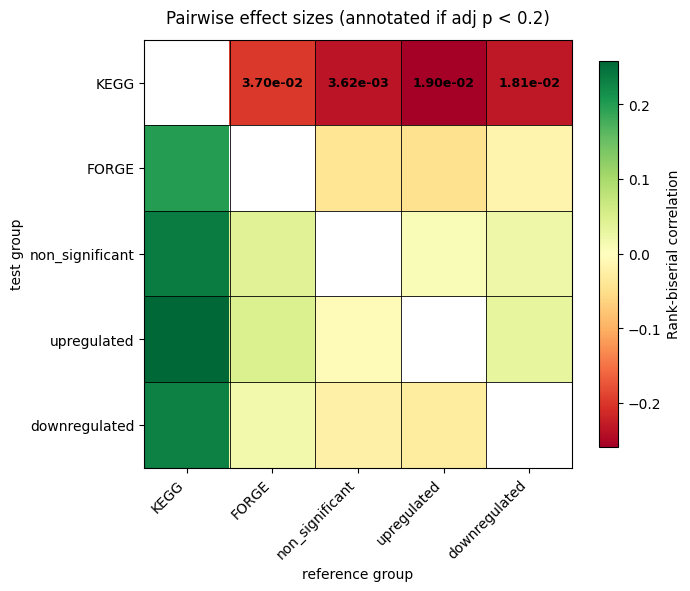

In [25]:
from matplotlib import colors

# --- Inputs ---
pvals = pval_mat_fdr.copy()
effects = rbc_mat.copy()

# mask diagonal
np.fill_diagonal(pvals.values, np.nan)
np.fill_diagonal(effects.values, np.nan)

# significance mask
sig_mask = pvals < 0.2

# --- derive limits from data ---
vmin = np.nanmin(effects.values)
vmax = np.nanmax(effects.values)

# ensure symmetry around 0 (important for interpretation)
lim = max(abs(vmin), abs(vmax))
vmin, vmax = -lim, lim

# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 6))

norm = colors.TwoSlopeNorm(
    vmin=vmin,
    vcenter=0,
    vmax=vmax
)

im = ax.imshow(
    effects,
    cmap='RdYlGn',
    norm=norm
)

# ticks
ax.set_xticks(range(len(effects.columns)))
ax.set_yticks(range(len(effects.index)))
ax.set_xticklabels(effects.columns, rotation=45, ha='right')
ax.set_yticklabels(effects.index)

# gridlines
ax.set_xticks(np.arange(-.5, len(effects.columns), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(effects.index), 1), minor=True)
ax.grid(which='minor', color='black', linewidth=0.6)
ax.tick_params(which='minor', bottom=False, left=False)

# annotate only significant cells (adj p < 0.2)
for i in range(effects.shape[0]):
    for j in range(effects.shape[1]):
        if sig_mask.iloc[i, j]:
            p = pvals.iloc[i, j]

            ax.text(
                j, i,
                f"{p:.2e}",          # scientific notation for p-values
                ha='center',
                va='center',
                fontsize=9,
                fontweight='bold',
                color='black'
            )

# colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label('Rank-biserial correlation', rotation=90)

ax.set_title(
    'Pairwise effect sizes (annotated if adj p < 0.2)',
    pad=12
)
plt.xlabel('reference group')
plt.ylabel('test group')
plt.tight_layout()
plt.savefig('/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Figs/EGFR_RWR_significance.pdf', dpi = 300, bbox_inches = 'tight')
plt.show()


the rows are the reference group: read as w.r.t forge genes, kegg genes have significantly lower rwr probabilites

##### Precily vs forge comparison

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
import os
from forge_class_instance3 import FORGE
%matplotlib inline

2026-01-28 17:56:49.213315: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/sreeramp/miniconda3/envs/precily_tf_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
forge_model = FORGE.load_forge(path='/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Models/optuna_models/ERLOTINIB_EGFR_forgeModel_optuna100.pkl')

In [3]:
forge_model.__getstate__().keys()

dict_keys(['exp_path', 'dep_path', 'ic50_path', 'drug', 'target', 'test_cellLines', 'train_cellLines', 'mean_dep', 'mean_ic50', 'training_cv_splits', 'hcg_list', 'exp_hcg', 'mean_exp', 'std_exp', 'W', 'hD', 'hI'])

In [4]:
# get forge predictions for test cell lines
exp_data = pd.read_csv(forge_model.exp_path, header=0, index_col=0)
exp_test = (exp_data.loc[forge_model.test_cellLines, forge_model.hcg_list] - forge_model.mean_exp) / forge_model.std_exp
exp_test.shape

(137, 201)

In [5]:
forge_pred = exp_test @ forge_model.W @ forge_model.hI
forge_pred

,0
StrippedCellLineName,
HCC33,-3.206570
G401,-0.431058
YH13,1.491560
SKLMS1,2.273559
SUDHL10,-0.961441
...,...
KELLY,0.163829
HUH1,1.010974
HCC366,-0.150954


In [6]:
full_chemberta_data = pd.read_parquet(
    '../Data/scaled_hv_pes_chemberta.parquet')

In [7]:
len([cl for cl in full_chemberta_data['cell_line'].unique()
     if cl in forge_model.test_cellLines])


137

In [14]:
erlo_test_data = full_chemberta_data.loc[
    (full_chemberta_data['cell_line'].isin(forge_model.test_cellLines)) &
    (full_chemberta_data['drug_name'].str.upper().str.strip() == 'ERLOTINIB'),
    :
]

erlo_test_data.shape

(137, 2022)

In [15]:
erlo_test_data.set_index('cell_line', inplace=True)

In [16]:
erlo_test_data.head()

,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,TPSA,FractionCSP3,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,...,WP_UDPDERIVED_SUGARS_SYNTHESIS_IN_FIBROBLASTS,WP_VALPROIC_ACID_PATHWAY,WP_VEDOLIZUMAB_THERAPY_FOR_INFLAMMATORY_BOWEL_DISEASE,WP_VISUAL_CYCLE,WP_VITAMIN_A1_AND_A5X_PATHWAYS,WP_VITAMIN_B6DEPENDENT_AND_RESPONSIVE_DISORDERS,WP_WNTBETACATENIN_SIGNALING_INHIBITORS_IN_CURRENT_AND_PAST_CLINICAL_TRIALS,WP_WNT_SIGNALING_IN_ADULT_HIPPOCAMPAL_NEUROGENESIS,scaled_ic50,drug_name
cell_line,,,,,,,,,,,,,,,,,,,,,
22RV1,-0.398033,-0.387198,-0.398172,-0.28,-0.522694,-0.242424,0.0,0.0,0.0,-0.5,...,-0.423827,1.040696,-1.528110,0.282063,-0.697053,0.759775,-0.870303,0.689314,0.405680,ERLOTINIB
42MGBA,-0.398033,-0.387198,-0.398172,-0.28,-0.522694,-0.242424,0.0,0.0,0.0,-0.5,...,0.453542,-0.384049,0.515939,-0.274552,0.273584,-0.163485,-0.057254,0.016049,0.526810,ERLOTINIB
769P,-0.398033,-0.387198,-0.398172,-0.28,-0.522694,-0.242424,0.0,0.0,0.0,-0.5,...,0.817489,0.594624,0.282751,-0.511184,-0.322653,0.035031,-0.926242,-0.563760,0.112823,ERLOTINIB
8505C,-0.398033,-0.387198,-0.398172,-0.28,-0.522694,-0.242424,0.0,0.0,0.0,-0.5,...,-0.039655,-0.848419,0.127736,-0.694490,0.440525,0.039210,0.259710,-0.280235,0.831033,ERLOTINIB
A2058,-0.398033,-0.387198,-0.398172,-0.28,-0.522694,-0.242424,0.0,0.0,0.0,-0.5,...,0.544537,-0.801677,0.163931,-0.178015,0.467905,-0.630898,0.492900,0.281221,0.279338,ERLOTINIB


In [17]:
y_test_df = erlo_test_data['scaled_ic50']
erlo_test_data.drop(columns = ['drug_name', 'scaled_ic50'], inplace=True)

/tmp/ipykernel_2453735/3512301021.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  erlo_test_data.drop(columns = ['drug_name', 'scaled_ic50'], inplace=True)


In [18]:
erlo_test_data.head()

,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,TPSA,FractionCSP3,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,...,WP_TYPE_I_COLLAGEN_SYNTHESIS_IN_THE_CONTEXT_OF_OSTEOGENESIS_IMPERFECTA,WP_TYPE_I_INTERFERON_INDUCTION_AND_SIGNALING_DURING_SARSCOV2_INFECTION,WP_UDPDERIVED_SUGARS_SYNTHESIS_IN_FIBROBLASTS,WP_VALPROIC_ACID_PATHWAY,WP_VEDOLIZUMAB_THERAPY_FOR_INFLAMMATORY_BOWEL_DISEASE,WP_VISUAL_CYCLE,WP_VITAMIN_A1_AND_A5X_PATHWAYS,WP_VITAMIN_B6DEPENDENT_AND_RESPONSIVE_DISORDERS,WP_WNTBETACATENIN_SIGNALING_INHIBITORS_IN_CURRENT_AND_PAST_CLINICAL_TRIALS,WP_WNT_SIGNALING_IN_ADULT_HIPPOCAMPAL_NEUROGENESIS
cell_line,,,,,,,,,,,,,,,,,,,,,
22RV1,-0.398033,-0.387198,-0.398172,-0.28,-0.522694,-0.242424,0.0,0.0,0.0,-0.5,...,-0.474864,-1.016975,-0.423827,1.040696,-1.528110,0.282063,-0.697053,0.759775,-0.870303,0.689314
42MGBA,-0.398033,-0.387198,-0.398172,-0.28,-0.522694,-0.242424,0.0,0.0,0.0,-0.5,...,1.160365,0.126007,0.453542,-0.384049,0.515939,-0.274552,0.273584,-0.163485,-0.057254,0.016049
769P,-0.398033,-0.387198,-0.398172,-0.28,-0.522694,-0.242424,0.0,0.0,0.0,-0.5,...,-0.171212,0.275501,0.817489,0.594624,0.282751,-0.511184,-0.322653,0.035031,-0.926242,-0.563760
8505C,-0.398033,-0.387198,-0.398172,-0.28,-0.522694,-0.242424,0.0,0.0,0.0,-0.5,...,0.633552,-0.223886,-0.039655,-0.848419,0.127736,-0.694490,0.440525,0.039210,0.259710,-0.280235
A2058,-0.398033,-0.387198,-0.398172,-0.28,-0.522694,-0.242424,0.0,0.0,0.0,-0.5,...,0.656103,-0.785551,0.544537,-0.801677,0.163931,-0.178015,0.467905,-0.630898,0.492900,0.281221


In [19]:
# get 5-fold predictions from precily
precily_model_dir = '/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Models/precily_tf_models/erlotinib_forge_overlap'
pred_vals = {}
for i in range(1,6):
    model_path = os.path.join(precily_model_dir, f"precily_tf_full_train_fold{str(i)}.hdf5")
    
    if os.path.exists(model_path):
        # print('True')
        precily_model = tf.keras.models.load_model(model_path, compile=False)
        test_preds_fold = precily_model.predict(erlo_test_data)
        pred_vals[f'fold{str(i)}'] = test_preds_fold.ravel()
        

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 177ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 202ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 191ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 188ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 192ms/step


In [24]:
precily_preds = pd.DataFrame(pred_vals)
precily_preds.head()

,fold1,fold2,fold3,fold4,fold5
0,-0.271807,-0.010908,0.103460,0.415862,0.074554
1,0.184370,0.028907,0.421664,0.123836,-0.050625
2,0.512730,0.009427,0.468080,0.571484,0.767933
3,0.382179,0.092745,0.586936,0.094080,0.030738
4,0.689875,0.393862,0.428673,0.302173,0.200661


In [25]:
# Mean across folds (row-wise)
precily_preds['mean_pred'] = precily_preds.mean(axis=1)

# Make sure lengths match before assigning
assert len(precily_preds) == len(forge_model.test_cellLines), \
    "Row count mismatch between precily_preds and test_cellLines"

# Assign cell lines
precily_preds['cell_line'] = erlo_test_data.index

precily_preds.set_index('cell_line', inplace=True)
# Add forge predictions (must be same length or same index)
precily_preds['forge_preds'] = forge_pred


In [26]:
precily_preds.head()

,fold1,fold2,fold3,fold4,fold5,mean_pred,forge_preds
cell_line,,,,,,,
22RV1,-0.271807,-0.010908,0.103460,0.415862,0.074554,0.062232,0.292963
42MGBA,0.184370,0.028907,0.421664,0.123836,-0.050625,0.141630,1.702960
769P,0.512730,0.009427,0.468080,0.571484,0.767933,0.465931,0.410624
8505C,0.382179,0.092745,0.586936,0.094080,0.030738,0.237336,0.759682
A2058,0.689875,0.393862,0.428673,0.302173,0.200661,0.403049,0.245622


In [28]:
y_test_df

cell_line
22RV1      0.405680
42MGBA     0.526810
769P       0.112823
8505C      0.831033
A2058      0.279338
             ...   
UBLC1     -2.979743
UWB1289   -0.992367
WSUNHL    -0.758854
YD15      -1.514131
YH13       0.452202
Name: scaled_ic50, Length: 137, dtype: float64

In [29]:
# y_test_df.set_index('cell_line', inplace=True)
precily_preds['scaled_ic50'] = y_test_df

In [30]:
precily_preds['forge_raw_pred'] = precily_preds['forge_preds'] + forge_model.mean_ic50

In [31]:
precily_preds.head()

,fold1,fold2,fold3,fold4,fold5,mean_pred,forge_preds,scaled_ic50,forge_raw_pred
cell_line,,,,,,,,,
22RV1,-0.271807,-0.010908,0.103460,0.415862,0.074554,0.062232,0.292963,0.405680,5.594028
42MGBA,0.184370,0.028907,0.421664,0.123836,-0.050625,0.141630,1.702960,0.526810,7.004025
769P,0.512730,0.009427,0.468080,0.571484,0.767933,0.465931,0.410624,0.112823,5.711689
8505C,0.382179,0.092745,0.586936,0.094080,0.030738,0.237336,0.759682,0.831033,6.060747
A2058,0.689875,0.393862,0.428673,0.302173,0.200661,0.403049,0.245622,0.279338,5.546687


In [32]:
from scipy.stats import pearsonr, spearmanr

x = precily_preds['scaled_ic50']
y = precily_preds['mean_pred']

r, pval = pearsonr(x, y)
print(f"Pearson r = {r:.4f}, p-value = {pval:.3e}")
rho, pval = spearmanr(x, y)
print(f"Spearman rho = {rho:.4f}, p-value = {pval:.3e}")

Pearson r = 0.3674, p-value = 1.001e-05
Spearman rho = 0.4161, p-value = 4.257e-07


<Axes: xlabel='mean_pred', ylabel='scaled_ic50'>

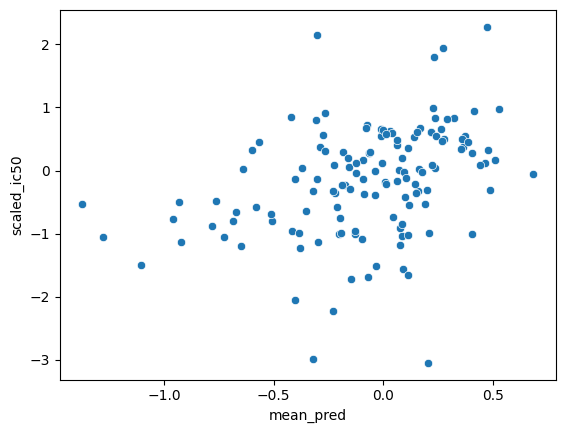

In [33]:
sns.scatterplot(data=precily_preds, x = 'mean_pred', y='scaled_ic50')

In [34]:
ic50_data = pd.read_csv(forge_model.ic50_path, header = 0, index_col = 0)
ic50_data = ic50_data.T
erlo_test_ic50 = ic50_data.loc[forge_model.test_cellLines, 'ERLOTINIB']
erlo_test_ic50.shape


(137,)

In [35]:
ic50_data.head()

drug,ABIRATERONE,ABT-751,AFATINIB,AFURESERTIB,ALECTINIB,ALISERTIB,ALPELISIB,ALVOCIDIB,AMG-319,AMUVATINIB,...,VELIPARIB,VENETOCLAX,VINBLASTINE,VINCRISTINE,VINORELBINE,VISMODEGIB,VORINOSTAT,VOXTALISIB,ZIBOTENTAN,ZILEUTON
1321N1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004,NaN,NaN,1.47000,NaN,NaN,3.18810,2.73910,-2.49402,NaN,NaN,...,7.57654,8.44648,NaN,-0.795137,NaN,NaN,2.770280,NaN,NaN,NaN
22RV1,NaN,NaN,2.80303,2.11144,4.80222,10.52470,3.52965,NaN,6.39615,4.37605,...,6.82060,3.05369,-6.48795,-3.765350,-6.55542,4.58268,1.086850,5.41142,7.35143,NaN
2313287,NaN,NaN,1.54454,1.40029,3.94753,4.46529,2.36674,NaN,4.35094,5.92903,...,6.74127,1.50728,-6.90162,-4.108140,-7.56164,5.42715,1.264830,4.18544,6.15199,NaN
253J,NaN,NaN,0.28527,NaN,NaN,4.87433,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.163836,NaN,NaN,0.940899,NaN,NaN,NaN


In [36]:
precily_preds['actual_IC50'] = erlo_test_ic50

In [38]:
x = precily_preds['forge_preds']
y = precily_preds['mean_pred']

r, pval = pearsonr(x, y)
print(f"Pearson r = {r:.4f}, p-value = {pval:.3e}")
rho, pval = spearmanr(x, y)
print(f"Spearman rho = {rho:.4f}, p-value = {pval:.3e}")

Pearson r = 0.6905, p-value = 1.015e-20
Spearman rho = 0.6868, p-value = 1.944e-20


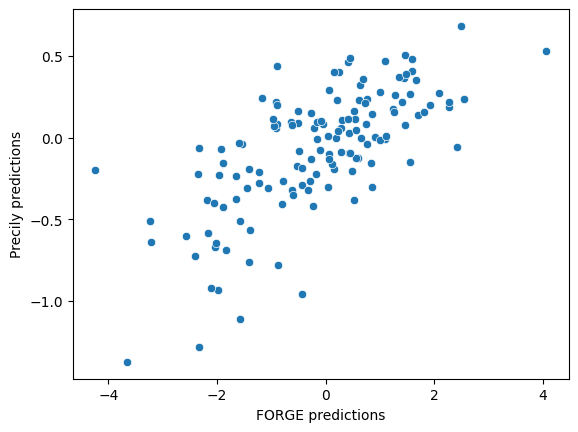

In [40]:
sns.scatterplot(x=x, y=y)
plt.xlabel('FORGE predictions')
plt.ylabel('Precily predictions')
plt.show()